# Custom datasets

In [1]:
import torch
from torch import nn
device = 'mps' if torch.mps.is_available() else 'cpu'
device

'mps'

# Get data
subset of Food101 with 3 classes

In [2]:
import requests
import zipfile
from pathlib import Path

data_path = Path('data')
image_path = data_path / 'pizza_steak_sushi'

if image_path.is_dir():
    print(f'{image_path} already exists, skipping download.')
else:
    print(f'Downloading and extracting data to {data_path}...')
    image_path.mkdir(parents=True, exist_ok=True)

# Download the zip file
with open(data_path / 'pizza_steak_sushi.zip', 'wb') as f:
    request = requests.get('https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip')
    print(f'Downloading: {request.status_code}')
    f.write(request.content)
    print('Download complete.')

# Extract the zip file
with zipfile.ZipFile(data_path / 'pizza_steak_sushi.zip', 'r') as zip_ref:
    print('Extracting files...')
    zip_ref.extractall(image_path)
    print('Extraction complete.')

data/pizza_steak_sushi already exists, skipping download.
Downloading: 200
Download complete.
Extracting files...
Extraction complete.


# 2. Becoming one with the data

In [3]:
import os
def walk_through_dir(dir_path):
    """Walks through dir_path returning its contents."""
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f'Found directory: {len(dirpath)}')
        print(f'Contains subdirectories: {len(dirnames)}')
        print(f'Contains files: {len(filenames)}')
        print('---')
walk_through_dir(image_path)

Found directory: 22
Contains subdirectories: 2
Contains files: 0
---
Found directory: 27
Contains subdirectories: 3
Contains files: 0
---
Found directory: 33
Contains subdirectories: 0
Contains files: 19
---
Found directory: 33
Contains subdirectories: 0
Contains files: 31
---
Found directory: 33
Contains subdirectories: 0
Contains files: 25
---
Found directory: 28
Contains subdirectories: 3
Contains files: 0
---
Found directory: 34
Contains subdirectories: 0
Contains files: 75
---
Found directory: 34
Contains subdirectories: 0
Contains files: 72
---
Found directory: 34
Contains subdirectories: 0
Contains files: 78
---


In [4]:
# Set up train and testing paths
train_dir = image_path / 'train'
test_dir = image_path / 'test'
train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

# 2.1 Visualizing and image

1. Get all of the image paths
2. Pick a random image oath using py's random.choice()
3. Get the image class name using `pathlib.Path.parent.stem`
4. Since we are working with images, let's open the image with pillow
5. We'll then show the image and print metadata

In [5]:
image_path

PosixPath('data/pizza_steak_sushi')

Image size: (512, 512)
Image format: JPEG
Image mode: RGB
Image class name: pizza


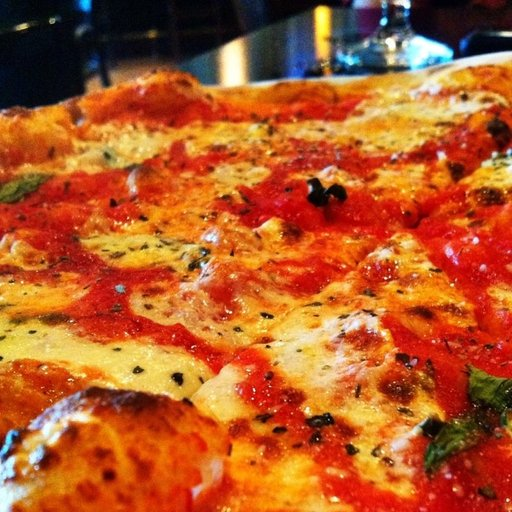

In [6]:
import random
from PIL import Image

random.seed(42)
image_path_list = list(image_path.glob('*/*/*.jpg'))
image_path_list[:5]

# Load in and view a random image
random_image_path = random.choice(image_path_list)
random_image_path

# Get the class names
class_names = random_image_path.parent.name
class_names

# Load in the image
img = Image.open(random_image_path)

# Print some metadata about the image
print(f'Image size: {img.size}')
print(f'Image format: {img.format}')
print(f'Image mode: {img.mode}')
print(f'Image class name: {class_names}')
img

(512, 512, 3)

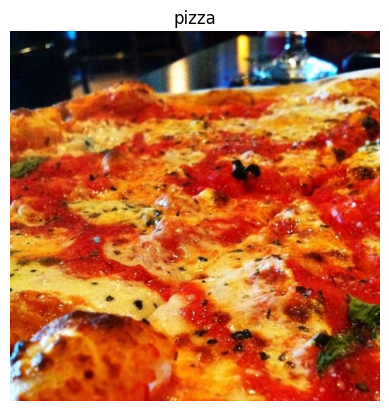

In [7]:
# Visualizing the image via matplotlib
import matplotlib.pyplot as plt
import numpy as np

plt.imshow(img)
plt.title(class_names)
plt.axis(False)

img_array = np.array(img)
img_array.shape

# 3. Transforming the data
Before we can use our data:

1. Turn data into tensors
2. Turn it into a `torch.utils.data.Dataset` and `DataLoader`

In [8]:
from torch.utils.data  import DataLoader
from torchvision import datasets, transforms

# Write a transform fro image
data_transform = transforms.Compose([
    # Resize the image to 64x64
    transforms.Resize((64, 64)),
    # Flip the image horizontally with a probability of 0.5
    transforms.RandomHorizontalFlip(p=0.5),
    # Convert the image to a tensor
    transforms.ToTensor()
])
data_transform(img).shape

torch.Size([3, 64, 64])

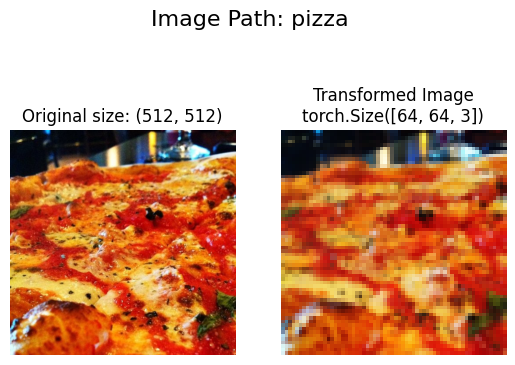

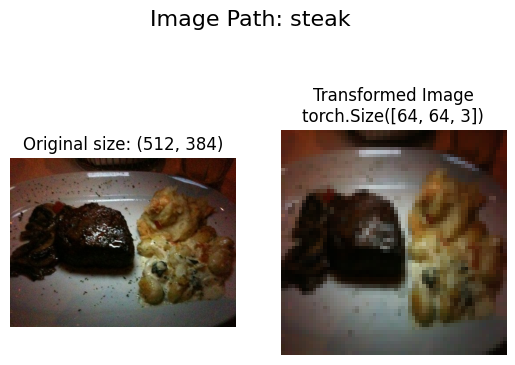

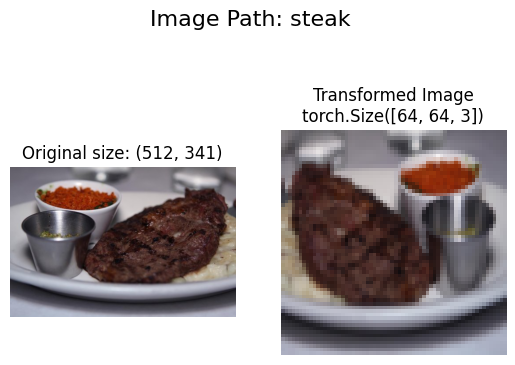

In [9]:
def plot_transformed_image(image_path, transform, n=3, seed=42):
    """Selects random images from images_path and compare to the original one"""
    if seed:
        random.seed(seed)
    random_image_path = random.sample(image_path_list, k=n)
    for image_path in random_image_path:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original size: {f.size}")
            ax[0].axis(False)

            transformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed Image\n{transformed_image.shape}")
            ax[1].axis(False)
            
            fig.suptitle(f"Image Path: {image_path.parent.stem}", fontsize=16)
plot_transformed_image(image_path_list, transform=data_transform, n=3, seed=42)

# 4. Option 1: Loading image data using `ImageFolder`

`torchvision.dataset.ImageFolder`

In [10]:
# Using ImageFolder to create datasets
train_data = datasets.ImageFolder(
    root=train_dir,
    transform=data_transform, # a transform we created earlier
    target_transform=None # no target transform
)
test_data = datasets.ImageFolder(
    root=test_dir,
    transform=data_transform, # a transform we created earlier
)
train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [11]:
# Get class names as list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [12]:
# Get class names as dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [13]:
# Check the length of out dataset
len(train_data), len(test_data)

(225, 75)

In [14]:
train_data.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

In [15]:
# Index on the train_data dataset
img,label = train_data[0][0], train_data[0][1]
print(f'Image tensor:\n{img}')
print(f'Label: {label}')
print(f'Class name: {class_names[label]}')
print(f"Image tensor shape: {img.shape}")
print(f"Image data type: {img.dtype}")

Image tensor:
tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.09

In [16]:
class_names[label]

'pizza'

original shape: torch.Size([3, 64, 64]) | permuted shape: torch.Size([64, 64, 3])
permuted image data type: torch.float32


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

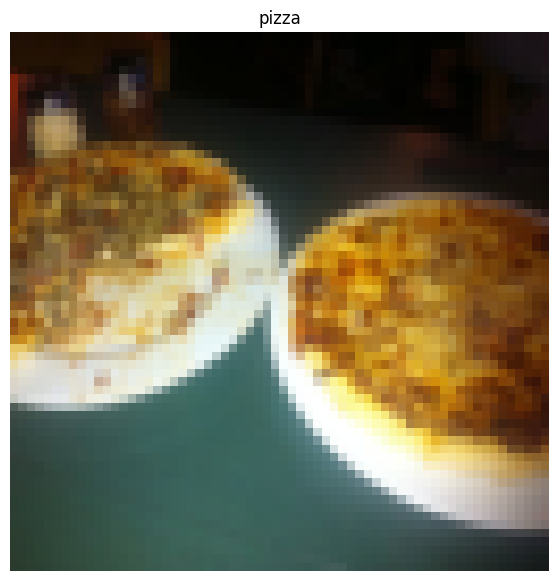

In [17]:
# Rearrange the order of dimensions
img_permuted = img.permute(1, 2, 0)

# Print out different shapes
print(f"original shape: {img.shape} | permuted shape: {img_permuted.shape}")
print(f"permuted image data type: {img_permuted.dtype}")

# Plot the images
plt.figure(figsize=(10,7))
plt.imshow(img_permuted)
plt.title(class_names[label])
plt.axis(False)

# 4.1 Turn loaded images into `DataLoader`s

It helps us to iterate and change the batchsize as well

In [18]:
# Turn train and test datasets into dataloaders
BATCH_SIZE = 1
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)
test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x161d59490>,
 <torch.utils.data.dataloader.DataLoader at 0x161ed40d0>)

In [19]:
img, label = next(iter(train_dataloader))

# Batch size will now be 1
print(f'Image batch shape: {img.shape} | Label batch shape: {label.shape}')

Image batch shape: torch.Size([1, 3, 64, 64]) | Label batch shape: torch.Size([1])


# 5 Option 2: Loading Image Data with a Custom `Dataset`

## Pros:
* Can create a `Dataset` out of almost anything
* Not limited to PyTorch prebuilt `Dataset` functions

## Cons:
* Even though you could create `Dataset` out of almost anything, it doesn't mean it will work...
* Using a custom `Dataset` ofetn results in us writing more code, which could be prone to errors or performance issues

In [20]:
import pathlib
from torch.utils.data import Dataset
from typing import Tuple, Dict, List

In [21]:
# Instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

## 5.1 Creating a helper function to get class names
We want a function to:
1. Get the class names using `os.scandir()`
2. Raise an error if the class names arne't found
3. Trun the class names into a dict and a list and return them

In [22]:
# Setup path for target directory
target_dir = train_dir
print(f"Target directory set to: {target_dir}")

# Get the class names from the target directory
class_names_found = sorted([entry.name for entry in list(os.scandir(target_dir))])
class_names_found

Target directory set to: data/pizza_steak_sushi/train


['pizza', 'steak', 'sushi']

In [23]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    """Finds the class folders in a dataset."""

    # Get the class names from the target directory
    classes = sorted([entry.name for entry in list(os.scandir(directory)) if entry.is_dir()])
    # Raise an error if no classes found
    if not classes:
        raise FileNotFoundError(f'No class folders found in {directory}.')
    # Create a dictionary of index labels
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx
find_classes(target_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

# 5.2 Create a custom `Dataset` to replicate `ImageFolder`

To Create our custom dataset, we want to:
1. Subclass `torch.utils.data.Dataset`
2. Init our subclasswith a target directory as well as transform if we'd like to transform our data.
3. Create severak attribute:
    * paths
    * transform
    * classes
    * class_to_idx
4. Create a function to `load_image()` for opening image
5. Overwrite the `__len()__` method to return the lenght of our dataset
6. Overwrite the `__getitem()__` method to return a given sample when passed and index


In [24]:
# Write a custom dataset class
class ImageFolderCustom(Dataset):
    # 1. Initialize the class
    def __init__(self,
                 targ_dir: str,
                 transform=None):
        # 2. Create class attributes
        # Get all image paths
        self.paths = list(pathlib.Path(targ_dir).glob('*/*.jpg'))
        # Setup transform
        self.transform = transform
        # Find class names and index labels
        self.class_names, self.class_to_idx = find_classes(targ_dir)
    
    # 3. Creating a function to load images
    def load_image(self, index:int) -> Image.Image:
        """Loads an image from a given index."""
        image_path = self.paths[index]
        return Image.open(image_path)
    
    # 4. Overwrite __len__ method
    def __len__(self) -> int:
        """Returns the length of the dataset."""
        return len(self.paths)
    
    # 5. Overwrite __getitem__ method
    def __getitem__(self, index:int) -> Tuple[torch.Tensor, int]:
        """Returns one sample of data, data and label (X, y)."""
        # Load in the image
        image = self.load_image(index)
        class_name = self.paths[index].parent.name # expects folder structure of class_name/image.jpg
        class_idx = self.class_to_idx[class_name]
        # Apply transform if necessary
        if self.transform:
            image = self.transform(image)
        return image, class_idx

In [25]:
# Create a transform
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [26]:
# Test out ImageFolderCustom
train_data_custom = ImageFolderCustom(
    targ_dir=train_dir,
    transform=train_transform
)
test_data_custom = ImageFolderCustom(
    targ_dir=test_dir,
    transform=test_transform
)
train_data_custom.class_names, train_data_custom.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [27]:
len(train_data_custom), len(test_data_custom)

(225, 75)

In [28]:
# Check for equality between original and custom datasets
print(f'Are the lengths equal? {len(train_data) == len(train_data_custom) and len(test_data) == len(test_data_custom)}')

Are the lengths equal? True


# 5.3 Create a function to display images

1. Take in a `Dataset` and a number of other parameters such as class names and how many images to visualize
2. To Prevent the display getting out of hand, let's cap the number of image to see at 10.
3. Set the random seed for reproducibility
4. Get a list of random sample indexes from the target dataset.
5. Setup a matplotlib plot.
6. Loop through the random sample images and plot the target dataset
7. Make sure the dimentions of our images line up with matplotlib

In [29]:
# Create a function to take in a dataset

def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
    # 1. Adjust display settings
    if n > 10:
        n = 10
        display_shape = False
        print(f"For display purposes, n has been set to 10 and display_shape to False.")
    
    # 2. Set random seed
    if seed:
        random.seed(seed)
    
    # 3. Get random sample indexes
    random_sample_idx = random.sample(range(len(dataset)), k=n)
    
    # 4. Plot the images
    plt.figure(figsize=(16,8))

    # 5. Loop through random sample indexes
    for i, targ_sample in enumerate(random_sample_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]
    
        # 6. Rearrange the image dimensions
        targ_image_adjust = targ_image.permute(1, 2, 0)

        # Plot the image
        plt.subplot(2, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis(False)
        if classes:
            title = f"Class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nShape: {targ_image_adjust.shape}"
        plt.title(title, fontsize=10)

In [30]:
random.sample(range(len(train_data_custom)), k=10)

[62, 57, 35, 188, 26, 173, 189, 139, 22, 151]

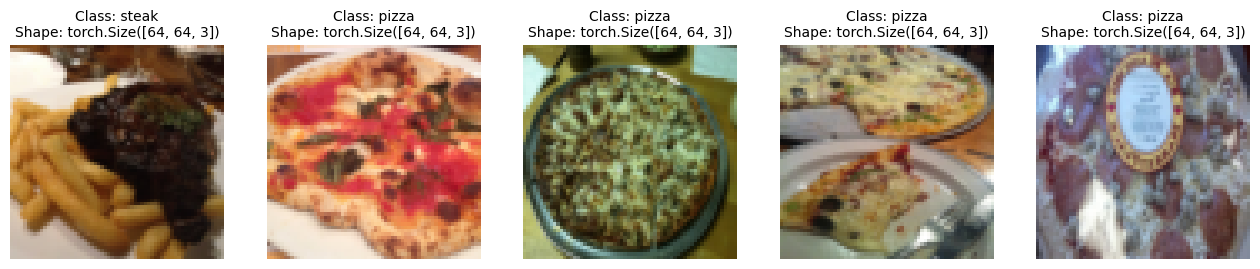

In [31]:
# Display random images from the ImageFolder created Dataset
display_random_images(train_data, n=5, classes=class_names,seed=None)

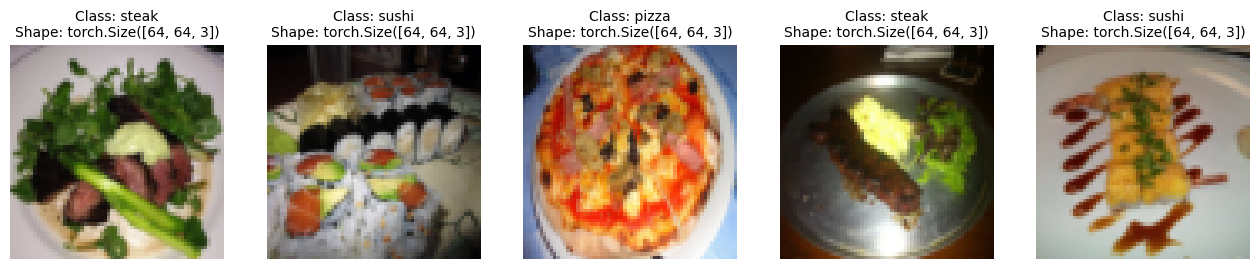

In [32]:
# Display random images from custom dataset
display_random_images(
    dataset=train_data_custom,
    classes=train_data_custom.class_names,
    n=5,
    display_shape=True,
    seed=None
)

# 5.4 Turn custom loaded images into `DataLoader`s

In [33]:
BATCH_SIZE = 32
train_dataloader_custom = DataLoader(
    dataset=train_data_custom,
    batch_size=BATCH_SIZE,
    shuffle=True
)
test_dataloader_custom = DataLoader(
    dataset=test_data_custom,
    batch_size=BATCH_SIZE,
    shuffle=False
)
train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x162928090>,
 <torch.utils.data.dataloader.DataLoader at 0x162b15610>)

In [34]:
# Get image and label from custom dataloader
img_custom, label_custom = next(iter(train_dataloader_custom))
# Batch size will now be 32
print(f'Image batch shape: {img_custom.shape} | Label batch shape: {label_custom.shape}')

Image batch shape: torch.Size([32, 3, 64, 64]) | Label batch shape: torch.Size([32])


# 6. Other froms of transform (data augmentation)
Artificially increasing the number of data

In [35]:
# Let's look at TrivialAugmentation
from torchvision import transforms
train_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=10),
    transforms.ToTensor()
])
test_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [36]:
# Get all image paths
image_paths = list(pathlib.Path(train_dir).glob('*/*.jpg'))
image_paths[:5]

[PosixPath('data/pizza_steak_sushi/train/steak/239025.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/1598345.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/3074367.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/2979061.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/914570.jpg')]

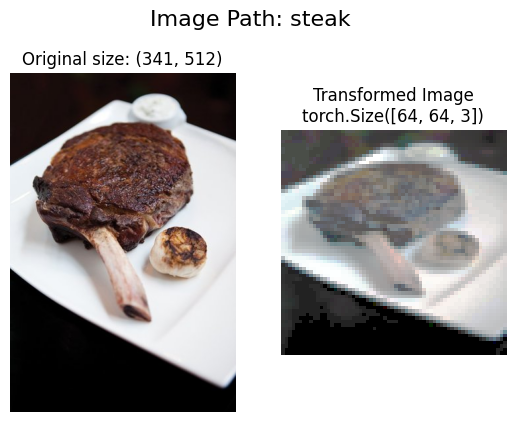

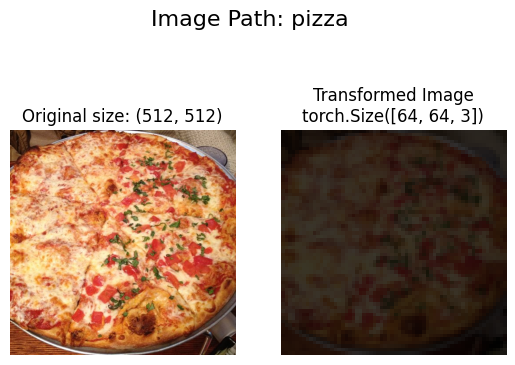

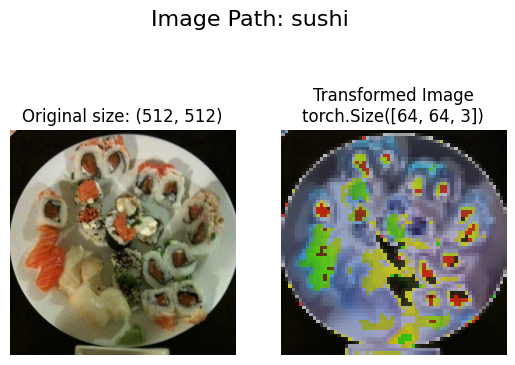

In [37]:
# Plot random images with TrivialAugmentation
plot_transformed_image(image_paths, transform=train_transform, n=3, seed=None)

# 7. Model 0: TinyVGG without data augmentation

### 7.1 Creating transforms and loading data for Model 0

In [38]:
# Create simple transform
simple_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [39]:
# 1. Load and transform an image
from torchvision import datasets, transforms
train_data_simple = datasets.ImageFolder(
    root=train_dir,
    transform=simple_transform, # a simple transform we created earlier
)
test_data_simple = datasets.ImageFolder(
    root=test_dir,
    transform=simple_transform, # a simple transform we created earlier
)

# 2. Create dataloaders
BATCH_SIZE = 32
train_dataloader_simple = DataLoader(
    dataset=train_data_simple,
    batch_size=BATCH_SIZE,
    shuffle=True
)
test_dataloader_simple = DataLoader(
    dataset=test_data_simple,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 7.2 Create TinyVGG model class

In [48]:
class TinyVGG(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2),
            nn.Dropout(0.25)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units * 3,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units * 3),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units * 3,
                      out_channels=hidden_units * 3,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units * 3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2),
            nn.Dropout(0.25)
        )
        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units * 3,
                      out_channels=hidden_units * 4,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units * 4),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units * 4,
                      out_channels=hidden_units * 4,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units * 4),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        # Alternative: use AdaptiveAvgPool2d to reduce spatial dims to 1x1

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # Reduces to 1x1 spatial size
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(in_features=hidden_units * 4,
                      out_features=output_shape)
            )
    
    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.conv_block_3(x)
        return self.classifier(x)

In [49]:
torch.manual_seed(42)
model_0 = TinyVGG(
    input_shape=3,
    hidden_units=32,
    output_shape=len(class_names)
).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(32, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)


# 7.3 Try a forwards pass on a single image (to test the model)

In [50]:
# Get a single image batch
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [51]:
# Try a forward pass
model_0(image_batch.to(device))

tensor([[ 1.8019,  0.8858, -0.4955],
        [ 1.7445, -0.5444,  0.0035],
        [ 0.9152, -0.6134, -0.5157],
        [ 1.4652, -0.4745, -0.6029],
        [ 2.1013,  0.7203, -0.6690],
        [ 2.1814, -0.1682,  0.9590],
        [ 1.3463, -0.2659, -0.5971],
        [ 1.8158, -0.0024, -0.8652],
        [ 0.6410,  0.0469, -0.1519],
        [ 1.0181,  0.9305,  0.5335],
        [ 0.5479, -0.5304, -0.5027],
        [ 1.4896, -0.1955, -0.2819],
        [ 0.9387, -1.4803, -0.0054],
        [ 1.0893,  0.1084, -1.0228],
        [ 1.2326, -0.2207, -1.2282],
        [ 1.2907,  1.0916,  0.0660],
        [-0.2840,  0.0440, -0.3901],
        [ 0.3537,  0.1847, -0.3863],
        [ 1.4119, -0.9889,  1.0077],
        [ 1.7027, -0.5558, -0.3374],
        [ 1.8329, -0.1142, -1.2540],
        [ 2.2104, -0.8815, -0.6627],
        [ 1.1363,  0.2963, -1.2859],
        [ 1.6438, -0.6066, -0.6973],
        [ 1.6589,  0.0388, -0.3694],
        [ 0.9081,  0.2481, -0.2540],
        [ 1.0065,  0.1867, -0.4224],
 

# 7.4 `torchinfo` to get an idea of the shapes going through our model

In [52]:
pip install torchinfo

Note: you may need to restart the kernel to use updated packages.


In [53]:
import torchinfo
from torchinfo import summary
summary(model_0, input_size=(32, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [32, 3]                   --
├─Sequential: 1-1                        [32, 32, 32, 32]          --
│    └─Conv2d: 2-1                       [32, 32, 64, 64]          896
│    └─BatchNorm2d: 2-2                  [32, 32, 64, 64]          64
│    └─ReLU: 2-3                         [32, 32, 64, 64]          --
│    └─Conv2d: 2-4                       [32, 32, 64, 64]          9,248
│    └─BatchNorm2d: 2-5                  [32, 32, 64, 64]          64
│    └─ReLU: 2-6                         [32, 32, 64, 64]          --
│    └─MaxPool2d: 2-7                    [32, 32, 32, 32]          --
│    └─Dropout: 2-8                      [32, 32, 32, 32]          --
├─Sequential: 1-2                        [32, 96, 16, 16]          --
│    └─Conv2d: 2-9                       [32, 96, 32, 32]          27,744
│    └─BatchNorm2d: 2-10                 [32, 96, 32, 32]          192
│    └

# 7.5 Create train and test loops functions


In [54]:
# Create train_step()
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device,
               clip_grad_norm: float | None = None):
    # 1. Set the model to training mode
    model.train()
    # 2. Setup train loss and accuracy values
    train_loss, train_acc = 0, 0
    # 3. Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # 4. Send data to target device
        X, y = X.to(device), y.to(device)
        # 5. Forward pass
        y_pred = model(X)
        # 6. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        # 7. Optimizer zero grad
        optimizer.zero_grad()
        # 8. Backward pass
        loss.backward()
        # 9. Optional gradient clipping
        if clip_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
        # 10. Optimizer step
        optimizer.step()
        # 11. Calculate and accumulate loss and accuracy values
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)
    # 12. Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [55]:
# Create test_step()
def test_step(model: torch.nn.Module,
                dataloader: torch.utils.data.DataLoader,
                loss_fn:torch.nn.Module,device: torch.device):
        # 1. Set the model to evaluation mode
        model.eval()
        # 2. Setup test loss and accuracy values
        test_loss, test_acc = 0, 0
        # 3. Turn on inference context manager
        with torch.inference_mode():
            
            # 4. Loop through data loader batches
            for batch, (X, y) in enumerate(dataloader):
                
                # 5. Send data to target device
                X, y = X.to(device), y.to(device)
                
                # 6. Forward pass
                test_pred_logits = model(X)
                
                # 7. Calculate loss
                loss = loss_fn(test_pred_logits, y)
                test_loss += loss.item()

                # 8. Calculate and accumulate accuracy values
                test_pred_labels = test_pred_logits.argmax(dim=1)
                test_acc += (test_pred_labels == y).sum().item()/len(test_pred_labels)
        
        # 9. Adjust metrics to get average loss and accuracy per batch
        test_loss = test_loss / len(dataloader)
        test_acc = test_acc / len(dataloader)
        return test_loss, test_acc

# 7.6 Creating a `train()` function to combine `train_step()` and `test_step()`

In [56]:
from tqdm.auto import tqdm
# Create function to train and test model
def train(model: torch.nn.Module,
                            train_dataloader: torch.utils.data.DataLoader,
                            test_dataloader: torch.utils.data.DataLoader,
                            optimizer: torch.optim.Optimizer,
                            loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
                            epochs: int=5,
                            device=device,
                            scheduler: torch.optim.lr_scheduler._LRScheduler | None = None,
                            clip_grad_norm: float | None = None):
        
        # 1. Create results dictionary
        results = {
            'train_loss': [],
            'train_acc': [],
            'test_loss': [],
            'test_acc': []
        }

        # 2. Loop through training and testing steps for a number of epochs
        for epoch in tqdm(range(epochs)):
            train_loss, train_acc = train_step(model,
                                            train_dataloader,
                                            loss_fn,
                                            optimizer,
                                            device,
                                            clip_grad_norm=clip_grad_norm)
            test_loss, test_acc = test_step(model,
                                            test_dataloader,
                                            loss_fn,
                                            device)
            
            # 3. Scheduler step (after validation)
            if scheduler is not None:
                if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(test_loss)
                else:
                    scheduler.step()
            
            # 4. Print out what's happening
            print(f"Epoch: {epoch} | "
                f"train_loss: {train_loss:.4f} | "
                f"train_acc: {train_acc:.4f} | "
                f"test_loss: {test_loss:.4f} | "
                f"test_acc: {test_acc:.4f}")
            
            # 5. Store results
            results['train_loss'].append(train_loss)
            results['train_acc'].append(train_acc)
            results['test_loss'].append(test_loss)
            results['test_acc'].append(test_acc)
        return results

/Users/mclight/Downloads/GitHub/AI_Self-Study/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 7.7 Train and evaluate model 0

In [57]:
# set random seed
NUM_EPOCHS = 100

# Create model instance
model_0 = TinyVGG(
    input_shape=3,
    hidden_units=32,
    output_shape=len(class_names)
).to(device)

# Create optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer_0 = torch.optim.Adam(params=model_0.parameters(),
                              lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train and test the model
model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader_simple,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer_0,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS,
                        clip_grad_norm=1.0)
end_time = timer()

print(f'Total training time: {end_time-start_time:.3f} seconds')

  1%|          | 1/100 [00:01<02:37,  1.59s/it]

Epoch: 0 | train_loss: 0.9894 | train_acc: 0.5352 | test_loss: 1.1267 | test_acc: 0.1979


  2%|▏         | 2/100 [00:02<01:58,  1.21s/it]

Epoch: 1 | train_loss: 0.9774 | train_acc: 0.5039 | test_loss: 1.1997 | test_acc: 0.2500


  3%|▎         | 3/100 [00:03<01:45,  1.09s/it]

...

Epoch: 97 | train_loss: 0.4246 | train_acc: 0.8555 | test_loss: 1.7424 | test_acc: 0.5890


 99%|█████████▉| 99/100 [01:31<00:00,  1.10it/s]

Epoch: 98 | train_loss: 0.1727 | train_acc: 0.9844 | test_loss: 1.9936 | test_acc: 0.6089


100%|██████████| 100/100 [01:32<00:00,  1.08it/s]

Epoch: 99 | train_loss: 0.5072 | train_acc: 0.8555 | test_loss: 0.9979 | test_acc: 0.6515
Total training time: 92.563 seconds


# 7.8 Plot the loss curves

In [58]:
# get model_0 results
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [59]:
def plot_loss_curves(results: Dict[str, List[float]]):
    """Plots training curves of a results dictionary."""
    # 1. Get the loss values from the results dictionary
    train_loss = results['train_loss']
    test_loss = results['test_loss']
    
    # 2. Get the accuracy values from the results dictionary
    train_acc = results['train_acc']
    test_acc = results['test_acc']
    
    # 3. Create number of epochs variable
    epochs = range(len(train_loss))
    
    # 4. Plot loss
    plt.figure(figsize=(15,7))
    plt.subplot(1,2,1)
    plt.plot(epochs, train_loss, label='Train Loss')
    plt.plot(epochs, test_loss, label='Test Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epochs')
    plt.legend()
    
    # 5. Plot accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs, train_acc, label='Train Accuracy')
    plt.plot(epochs, test_acc, label='Test Accuracy')
    plt.title('Accuracy Curves')
    plt.xlabel('Epochs')
    plt.legend()
    
    plt.show()

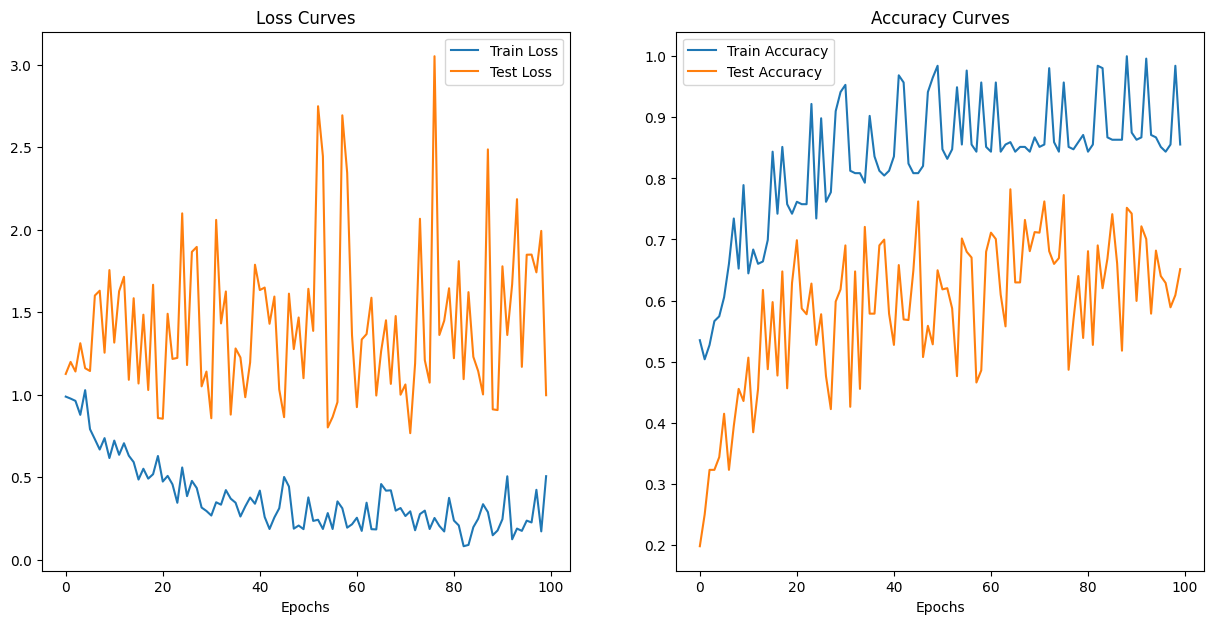

In [60]:
plot_loss_curves(model_0_results)

# 9. Model 1: TinyVGG with Data Augmentation
## 9.1 Create a transform with data augmentation

In [61]:
# Create training transform with TrivialAugmentation
from torchvision import transforms
train_trainsform_trivial = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform_simple = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

# 9.2 Create train and test `Dataset`s and `DataLoader`s with data augmentation

In [62]:
# Turn image folders into Datasets
train_data_augmented = datasets.ImageFolder(root=train_dir,
                                            transform=train_trainsform_trivial)
test_data_simple = datasets.ImageFolder(root=test_dir,
                                        transform=test_transform_simple)


In [63]:
# Turn our datasets into DataLoaders
BATCH_SIZE = 32

train_dataloader_augmented=DataLoader(dataset=train_data_augmented,
                                      batch_size=BATCH_SIZE,
                                      shuffle=True)
test_dataloader_augmented=DataLoader(dataset=test_data_simple,
                                      batch_size=BATCH_SIZE,
                                      shuffle=False)

# 9.3 Construct and train model 1

In [64]:
class TinyVGG(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2),
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units * 2,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units * 2,
                      out_channels=hidden_units * 2,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2),
        )
        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units * 2,
                      out_channels=hidden_units * 4,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units * 4,
                      out_channels=hidden_units * 4,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(in_features=hidden_units * 4,
                      out_features=output_shape)
        )
    
    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.conv_block_3(x)
        return self.classifier(x)

model_1 = TinyVGG(
    input_shape=3,
    hidden_units=32,
    output_shape=len(class_names)
).to(device)

# Recreate model_1 with corrected TinyVGG
model_1 = TinyVGG(
    input_shape=3,
    hidden_units=32,
    output_shape=len(class_names)
).to(device)

epochs = 100


loss_fn = nn.CrossEntropyLoss()
optimizer_1 = torch.optim.Adam(params=model_1.parameters(),
                              lr=0.001)

from timeit import default_timer as timer
start_time = timer()

model_1_results = train(model=model_1,
                        train_dataloader=train_dataloader_augmented,
                        test_dataloader=test_dataloader_augmented,
                        optimizer=optimizer_1,
                        loss_fn=loss_fn,
                        epochs=epochs,
                        clip_grad_norm=1.0)
end_time = timer()
print(f'Total training time: {end_time-start_time:.3f} seconds')

  0%|          | 0/100 [00:00<?, ?it/s]

  1%|          | 1/100 [00:00<01:28,  1.12it/s]

Epoch: 0 | train_loss: 1.0955 | train_acc: 0.3945 | test_loss: 1.0967 | test_acc: 0.2604


  2%|▏         | 2/100 [00:01<01:20,  1.22it/s]

Epoch: 1 | train_loss: 1.1006 | train_acc: 0.3047 | test_loss: 1.0983 | test_acc: 0.2604


...

Epoch: 97 | train_loss: 0.7633 | train_acc: 0.6016 | test_loss: 0.9368 | test_acc: 0.5265


 99%|█████████▉| 99/100 [01:16<00:00,  1.29it/s]

Epoch: 98 | train_loss: 0.7179 | train_acc: 0.6406 | test_loss: 0.8888 | test_acc: 0.5871


100%|██████████| 100/100 [01:17<00:00,  1.29it/s]

Epoch: 99 | train_loss: 0.6638 | train_acc: 0.7109 | test_loss: 1.0241 | test_acc: 0.4981
Total training time: 77.604 seconds


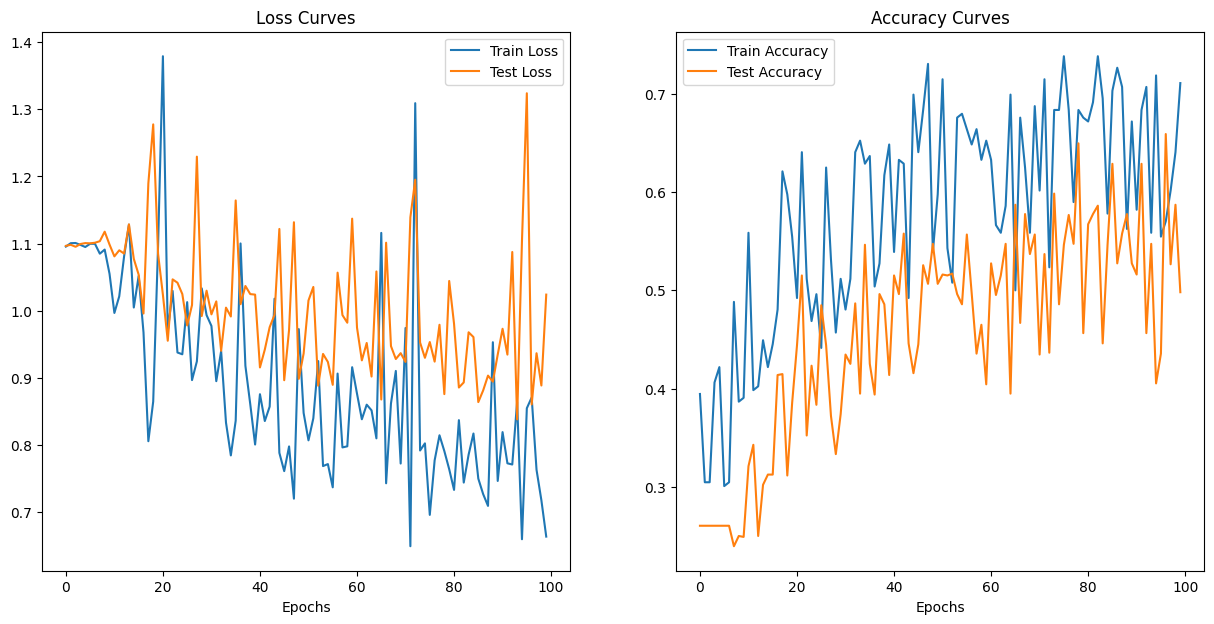

In [65]:
plot_loss_curves(model_1_results)

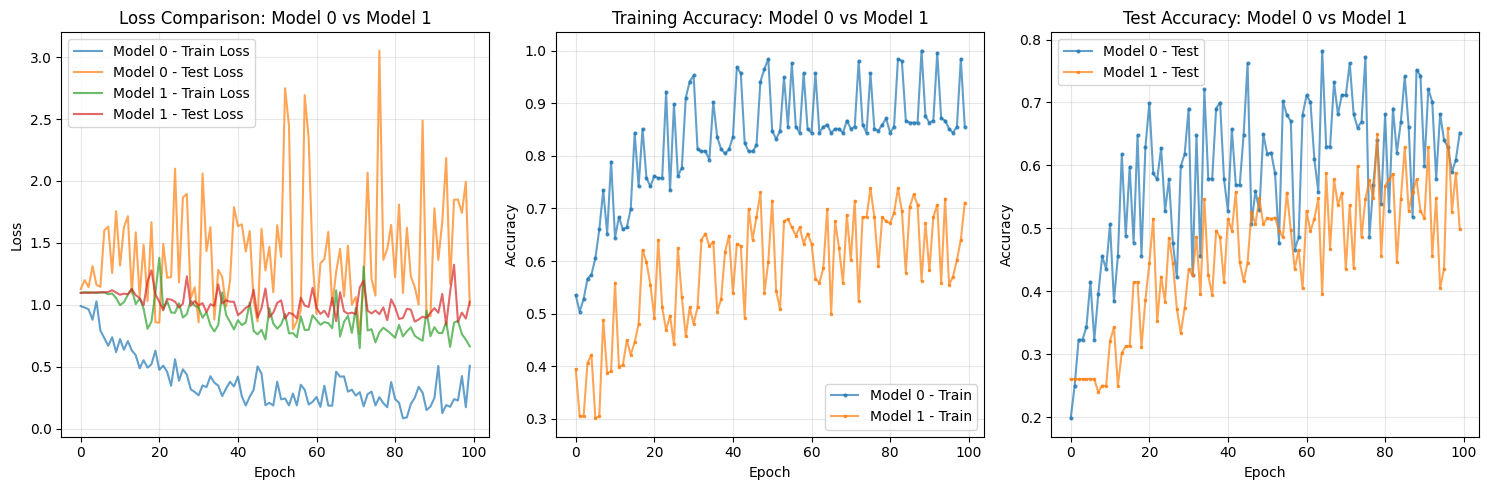

MODEL COMPARISON SUMMARY

Model 0 (No Augmentation):
  Final Train Loss: 0.5072
  Final Test Loss:  0.9979
  Final Train Acc:  0.8555
  Final Test Acc:   0.6515
  Best Test Acc:    0.7822 (Epoch 64)

Model 1 (With TrivialAugmentWide):
  Final Train Loss: 0.6638
  Final Test Loss:  1.0241
  Final Train Acc:  0.7109
  Final Test Acc:   0.4981
  Best Test Acc:    0.6591 (Epoch 96)

Improvement from Data Augmentation:
  Test Accuracy Improvement: +-0.1231 (-15.74%)


In [66]:
# Compare model_0 vs model_1 results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
epochs_range = range(len(model_0_results['train_loss']))
plt.plot(epochs_range, model_0_results['train_loss'], label='Model 0 - Train Loss', alpha=0.7)
plt.plot(epochs_range, model_0_results['test_loss'], label='Model 0 - Test Loss', alpha=0.7)
plt.plot(epochs_range, model_1_results['train_loss'], label='Model 1 - Train Loss', alpha=0.7)
plt.plot(epochs_range, model_1_results['test_loss'], label='Model 1 - Test Loss', alpha=0.7)
plt.title('Loss Comparison: Model 0 vs Model 1')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(epochs_range, model_0_results['train_acc'], label='Model 0 - Train', marker='o', markersize=2, alpha=0.7)
plt.plot(epochs_range, model_1_results['train_acc'], label='Model 1 - Train', marker='s', markersize=2, alpha=0.7)
plt.title('Training Accuracy: Model 0 vs Model 1')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(epochs_range, model_0_results['test_acc'], label='Model 0 - Test', marker='o', markersize=2, alpha=0.7)
plt.plot(epochs_range, model_1_results['test_acc'], label='Model 1 - Test', marker='s', markersize=2, alpha=0.7)
plt.title('Test Accuracy: Model 0 vs Model 1')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("MODEL COMPARISON SUMMARY")
print(f"\nModel 0 (No Augmentation):")
print(f"  Final Train Loss: {model_0_results['train_loss'][-1]:.4f}")
print(f"  Final Test Loss:  {model_0_results['test_loss'][-1]:.4f}")
print(f"  Final Train Acc:  {model_0_results['train_acc'][-1]:.4f}")
print(f"  Final Test Acc:   {model_0_results['test_acc'][-1]:.4f}")
print(f"  Best Test Acc:    {max(model_0_results['test_acc']):.4f} (Epoch {model_0_results['test_acc'].index(max(model_0_results['test_acc']))})")

print(f"\nModel 1 (With TrivialAugmentWide):")
print(f"  Final Train Loss: {model_1_results['train_loss'][-1]:.4f}")
print(f"  Final Test Loss:  {model_1_results['test_loss'][-1]:.4f}")
print(f"  Final Train Acc:  {model_1_results['train_acc'][-1]:.4f}")
print(f"  Final Test Acc:   {model_1_results['test_acc'][-1]:.4f}")
print(f"  Best Test Acc:    {max(model_1_results['test_acc']):.4f} (Epoch {model_1_results['test_acc'].index(max(model_1_results['test_acc']))})")

print(f"\nImprovement from Data Augmentation:")
print(f"  Test Accuracy Improvement: +{(max(model_1_results['test_acc']) - max(model_0_results['test_acc'])):.4f} ({((max(model_1_results['test_acc']) / max(model_0_results['test_acc']) - 1) * 100):.2f}%)")


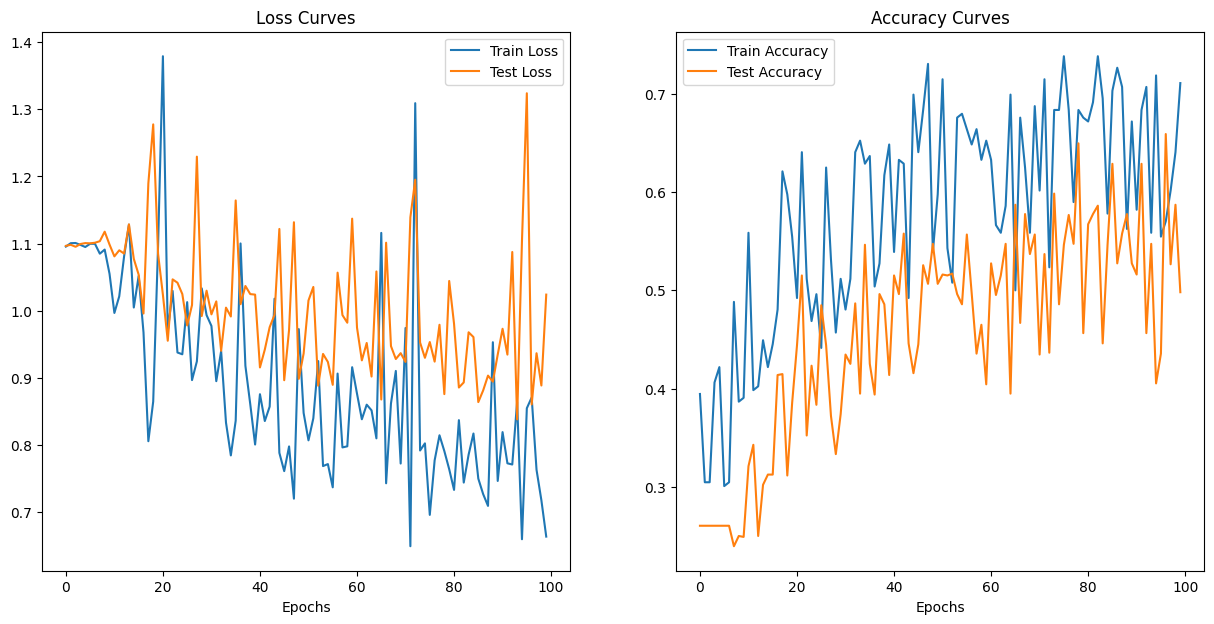

In [71]:
plot_loss_curves(model_1_results)

# 10. Compare Models

1. Hard coding (what we are doing)
2. PyTorch + Tensorboard
3. Weights $ Biases
4. MLFlow

In [72]:
import pandas as pd
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,0.989403,0.535156,1.126737,0.197917
1,0.977412,0.503906,1.199690,0.250000
2,0.963597,0.527344,1.141555,0.322917
3,0.878871,0.566406,1.313083,0.322917
4,1.028382,0.574219,1.161586,0.343750
...,...,...,...,...
95,0.237881,0.851562,1.849211,0.640152
96,0.226873,0.843750,1.850017,0.628788
97,0.424622,0.855469,1.742366,0.589015
98,0.172710,0.984375,1.993579,0.608902


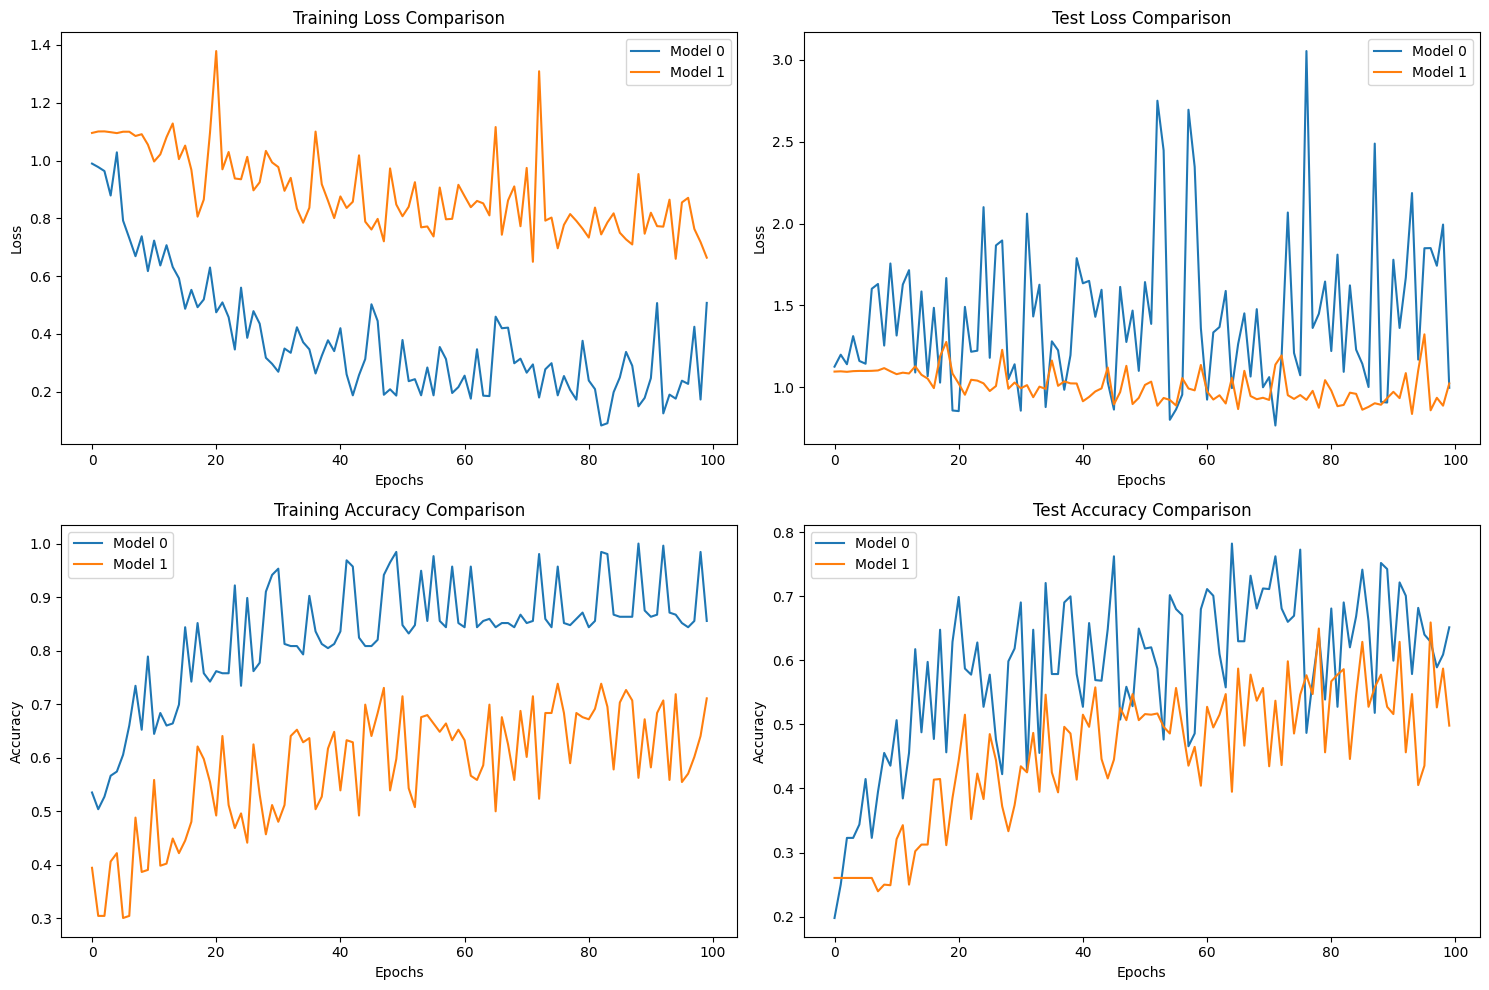

In [76]:
# Setup a plot
plt.figure(figsize=(15, 10))

# Epochs
epochs = range(len(model_0_df))

# Plot train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, model_0_df['train_loss'], label='Model 0')
plt.plot(epochs, model_1_df['train_loss'], label='Model 1')
plt.title('Training Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df['test_loss'], label='Model 0')
plt.plot(epochs, model_1_df['test_loss'], label='Model 1')
plt.title('Test Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot train accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df['train_acc'], label='Model 0')
plt.plot(epochs, model_1_df['train_acc'], label='Model 1')
plt.title('Training Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot test accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df['test_acc'], label='Model 0')
plt.plot(epochs, model_1_df['test_acc'], label='Model 1')
plt.title('Test Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# 11. Making a prediction on a custom image

In [80]:
import requests

custom_image_path = data_path/'custom_image_2.jpg'

## 11.1 Loading in a custom image with PyTorch

In [87]:
import torchvision

custom_image_uint8 = torchvision.io.read_image(str(custom_image_path)).type(torch.float32)/255.0
custom_image_uint8
print(f"Custom image tensor shape: {custom_image_uint8.shape} | dtype: {custom_image_uint8.dtype}")
print(f'Custom image data type: {type(custom_image_uint8)}')

Custom image tensor shape: torch.Size([3, 404, 720]) | dtype: torch.float32
Custom image data type: <class 'torch.Tensor'>


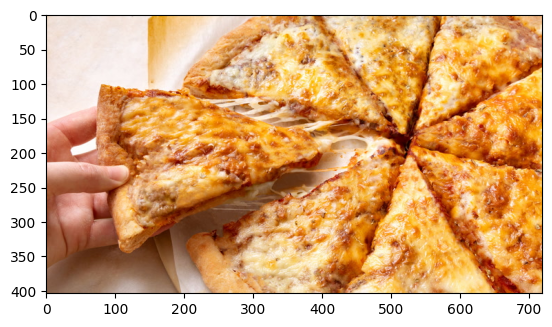

In [88]:
plt.imshow(custom_image_uint8.permute(1, 2, 0))

## 11.2 Making a orediction on a custom image with a trained PyTorch model

In [91]:
custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32)/255.0
custom_image

tensor([[[0.9412, 0.9373, 0.9412,  ..., 0.8745, 0.9059, 0.9843],
         [0.9373, 0.9333, 0.9373,  ..., 0.9020, 0.8784, 0.9059],
         [0.9412, 0.9373, 0.9333,  ..., 0.9176, 0.8941, 0.9216],
         ...,
         [0.5176, 0.5176, 0.5176,  ..., 0.9137, 0.9020, 0.8941],
         [0.5216, 0.5216, 0.5216,  ..., 0.9020, 0.8902, 0.8824],
         [0.5216, 0.5216, 0.5216,  ..., 0.8980, 0.8824, 0.8745]],

        [[0.8118, 0.8039, 0.8196,  ..., 0.6510, 0.7020, 0.7882],
         [0.8157, 0.8118, 0.8196,  ..., 0.6784, 0.6706, 0.7020],
         [0.8275, 0.8196, 0.8275,  ..., 0.6902, 0.6824, 0.7098],
         ...,
         [0.3765, 0.3765, 0.3765,  ..., 0.7529, 0.7451, 0.7373],
         [0.3804, 0.3804, 0.3804,  ..., 0.7333, 0.7255, 0.7176],
         [0.3804, 0.3804, 0.3804,  ..., 0.7176, 0.7098, 0.7020]],

        [[0.6902, 0.6941, 0.7059,  ..., 0.4824, 0.5490, 0.6510],
         [0.6941, 0.6980, 0.7098,  ..., 0.5020, 0.5059, 0.5490],
         [0.7098, 0.7098, 0.7216,  ..., 0.5020, 0.4980, 0.

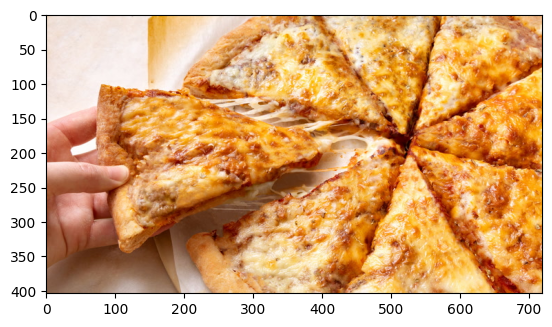

In [93]:
plt.imshow(custom_image.permute(1, 2, 0))

In [96]:
# Create a transform to match training data
custom_image_transform = transforms.Compose([
    transforms.Resize((64,64))
])

# Transform the custom image
custom_image_transformed = custom_image_transform(custom_image)
custom_image_transformed.shape

torch.Size([3, 64, 64])

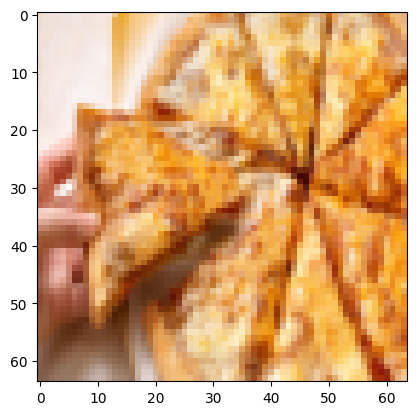

In [98]:
plt.imshow(custom_image_transformed.permute(1, 2, 0))

In [102]:
# Try to make a prediction on an image in uint8 format
# LOL image not in right device
model_1.eval()
with torch.inference_mode():
    custom_image_pred = model_1(custom_image_transformed.to(device))

RuntimeError: linear(): input and weight.T shapes cannot be multiplied (128x1 and 128x3)

In [86]:
custom_image_uint8.shape

torch.Size([3, 404, 720])

In [104]:
custom_image_transformed.shape, custom_image_transformed.unsqueeze(0).shape

(torch.Size([3, 64, 64]), torch.Size([1, 3, 64, 64]))

In [105]:
# Added batch size
model_1.eval()
with torch.inference_mode():
    custom_image_pred = model_1(custom_image_transformed.unsqueeze(0).to(device))

Note, to make a orediction on a custom image we had to:
* Load the image and turn it into a tensor
* Make sure the image was the same datatype as the model (torch.float32)
* Make surethe image was the same shapoe as the data the model was trained on (3x64x64) with a batch size ... (1,3,64,64)
* Make sure the image was on the same device as our model

In [106]:
# Convert logits to prediction probabilities
custom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
custom_image_pred_probs

tensor([[9.8360e-01, 9.1009e-05, 1.6304e-02]], device='mps:0')

In [107]:
# Convert prediction probabilities to labels
custom_image_pred_label = torch.argmax(custom_image_pred_probs, dim=1)
custom_image_pred_label

tensor([0], device='mps:0')

In [109]:
class_names[custom_image_pred_label]

'pizza'

### 11.3 Putting custom image together building a function

In [112]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        transform: transforms.Compose,
                        class_names: List[str] = None,
                        device: torch.device = device):
    # 1. Load in the image and convert to tensor
    image = torchvision.io.read_image(image_path).type(torch.float32)/255.0
    
    # 2. Transform the image
    if transform:
        image_transformed = transform(image)
    else:
        image_transformed = image
    
    model = model.to(device)

    # 3. Put model in eval mode and turn on inference mode
    model.eval()
    with torch.inference_mode():
        # 4. Make a prediction on the image with an added batch dimension
        pred_logits = model(image_transformed.unsqueeze(0).to(device))
        
        # 5. Convert logits to prediction probabilities
        pred_probs = torch.softmax(pred_logits, dim=1)
        
        # 6. Convert prediction probabilities to labels
        pred_label = torch.argmax(pred_probs, dim=1)
    
    # 7. Plot the image and prediction
    plt.imshow(image_transformed.permute(1, 2, 0))
    if class_names:
        print(f"Pred: {class_names[pred_label.cpu()]} | Prob: {pred_probs.max().cpu():.3f}")
    else:
        print(f"Pred label: {pred_label.cpu()} | Prob: {pred_probs.max().cpu():.3f}")
    plt.axis(False)

Pred: pizza | Prob: 1.000


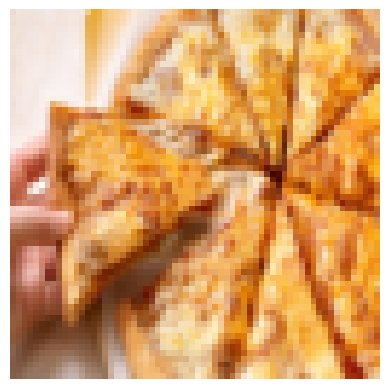

In [115]:
# Pred on our custom image
pred_and_plot_image(model=model_0,
                    image_path=str(custom_image_path),
                    transform=transforms.Compose([
                        transforms.Resize((64,64))
                    ]),
                    class_names=class_names,
                    device=device)

Pred: pizza | Prob: 0.722


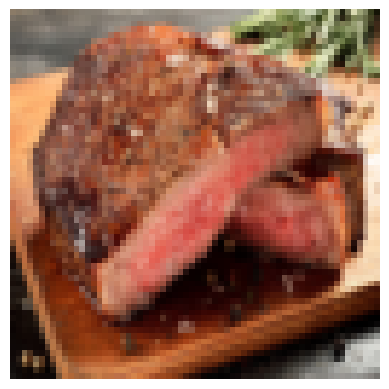

In [125]:
# Pred on our custom image
custom_image_path = data_path/'custom_image_4.jpg'
pred_and_plot_image(model=model_1,
                    image_path=str(custom_image_path),
                    transform=transforms.Compose([
                        transforms.Resize((64,64))
                    ]),
                    class_names=class_names,
                    device=device)

# 10. Model 2: TinyVGG with Hyperparameter Tuning

## Strategy:
1. **Increase model capacity**: hidden_units 32 → 64
2. **Adaptive learning rate**: Use ReduceLROnPlateau scheduler
3. **Stronger regularization**: Higher dropout, stronger augmentation
4. **Better optimizer**: AdamW with weight decay
5. **Early stopping**: Monitor best test accuracy


In [67]:
# Create stronger augmentation for model_2
train_transform_strong = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),  # Max strength
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

test_transform_normalized = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Create datasets with stronger augmentation
train_data_strong = datasets.ImageFolder(root=train_dir,
                                         transform=train_transform_strong)
test_data_normalized = datasets.ImageFolder(root=test_dir,
                                            transform=test_transform_normalized)

# Create dataloaders
BATCH_SIZE = 32
train_dataloader_strong = DataLoader(dataset=train_data_strong,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True)
test_dataloader_strong = DataLoader(dataset=test_data_normalized,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False)


In [68]:
# Enhanced TinyVGG with higher capacity (hidden_units=64)
class TinyVGGv2(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.3)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units * 2,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units * 2),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units * 2,
                      out_channels=hidden_units * 2,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units * 2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.3)
        )
        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units * 2,
                      out_channels=hidden_units * 4,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units * 4),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units * 4,
                      out_channels=hidden_units * 4,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units * 4),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.3)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(in_features=hidden_units * 4,
                      out_features=output_shape)
        )
    
    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.conv_block_3(x)
        return self.classifier(x)

# Initialize model_2
torch.manual_seed(42)
model_2 = TinyVGGv2(
    input_shape=3,
    hidden_units=64,  # Double the capacity
    output_shape=len(class_names)
).to(device)

model_2


TinyVGGv2(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.3, inplace=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=F

In [69]:
# Train model_2 with optimized hyperparameters
NUM_EPOCHS = 150

loss_fn = nn.CrossEntropyLoss()

# AdamW optimizer with weight decay (L2 regularization)
optimizer_2 = torch.optim.AdamW(params=model_2.parameters(),
                                lr=0.001,
                                weight_decay=1e-4)

# ReduceLROnPlateau scheduler for adaptive learning rate
scheduler_2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_2,
    mode='min',
    factor=0.5,
    patience=10,
    min_lr=1e-6
)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_2
model_2_results = train(model=model_2,
                        train_dataloader=train_dataloader_strong,
                        test_dataloader=test_dataloader_strong,
                        optimizer=optimizer_2,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS,
                        device=device,
                        scheduler=scheduler_2,
                        clip_grad_norm=1.0)

end_time = timer()
print(f'\nTotal training time: {end_time-start_time:.3f} seconds')


  1%|          | 1/150 [00:01<04:32,  1.83s/it]

Epoch: 0 | train_loss: 1.2513 | train_acc: 0.3086 | test_loss: 0.9908 | test_acc: 0.4205


  1%|▏         | 2/150 [00:03<04:02,  1.64s/it]

Epoch: 1 | train_loss: 1.0915 | train_acc: 0.4805 | test_loss: 1.1729 | test_acc: 0.3712


  2%|▏         | 3/150 [00:04<03:55,  1.60s/it]

...

Epoch: 147 | train_loss: 0.3698 | train_acc: 0.8945 | test_loss: 0.6455 | test_acc: 0.7121


 99%|█████████▉| 149/150 [03:42<00:01,  1.58s/it]

Epoch: 148 | train_loss: 0.4045 | train_acc: 0.8906 | test_loss: 0.5966 | test_acc: 0.8239


100%|██████████| 150/150 [03:43<00:00,  1.49s/it]

Epoch: 149 | train_loss: 0.4311 | train_acc: 0.7734 | test_loss: 0.6058 | test_acc: 0.8040

Total training time: 223.743 seconds


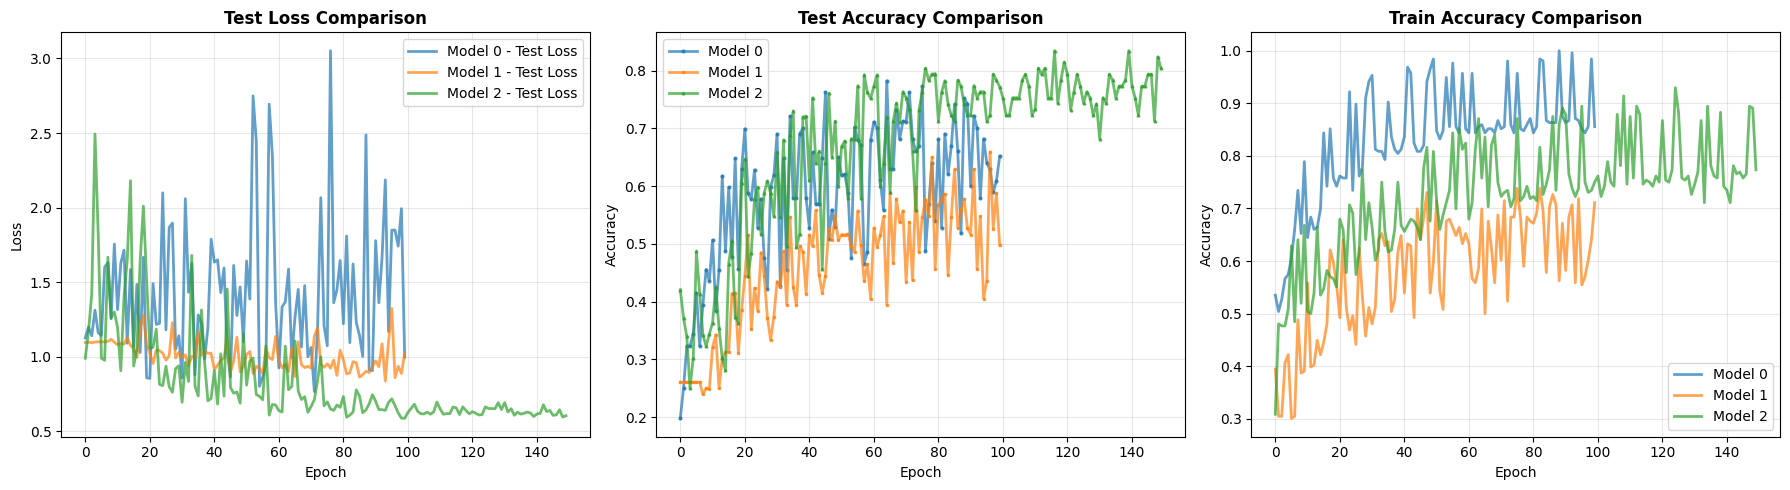

COMPREHENSIVE MODEL COMPARISON: Model 0 vs Model 1 vs Model 2

Model 0: No Augmentation, hidden=32
  ├─ Best Test Accuracy:    0.7822 (Epoch 64)
  ├─ Final Test Accuracy:   0.6515
  ├─ Final Train Loss:      0.5072
  ├─ Final Test Loss:       0.9979
  └─ Overfitting Gap:       -0.4907

Model 1: TrivialAugment, hidden=32, Adam
  ├─ Best Test Accuracy:    0.6591 (Epoch 96)
  ├─ Final Test Accuracy:   0.4981
  ├─ Final Train Loss:      0.6638
  ├─ Final Test Loss:       1.0241
  └─ Overfitting Gap:       -0.3603

Model 2: Strong Augment+Norm, hidden=64, AdamW+Scheduler
  ├─ Best Test Accuracy:    0.8343 (Epoch 116)
  ├─ Final Test Accuracy:   0.8040
  ├─ Final Train Loss:      0.4311
  ├─ Final Test Loss:       0.6058
  └─ Overfitting Gap:       -0.1747
BEST MODELS BY METRIC
  Best Final Accuracy........... Model 2 (0.8040)
  Best Peak Accuracy............ Model 0 (0.7822)
  Best Generalization........... Model 2 (0.1747)


In [70]:
# Compare all three models
plt.figure(figsize=(18, 5))

epochs_range = range(len(model_0_results['train_loss']))

plt.subplot(1, 3, 1)
plt.plot(epochs_range, model_0_results['test_loss'], label='Model 0 - Test Loss', alpha=0.7, linewidth=2)
plt.plot(epochs_range, model_1_results['test_loss'], label='Model 1 - Test Loss', alpha=0.7, linewidth=2)
plt.plot(range(len(model_2_results['test_loss'])), model_2_results['test_loss'], 
         label='Model 2 - Test Loss', alpha=0.7, linewidth=2)
plt.title('Test Loss Comparison', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(1, 3, 2)
plt.plot(epochs_range, model_0_results['test_acc'], label='Model 0', alpha=0.7, linewidth=2, marker='o', markersize=2)
plt.plot(epochs_range, model_1_results['test_acc'], label='Model 1', alpha=0.7, linewidth=2, marker='s', markersize=2)
plt.plot(range(len(model_2_results['test_acc'])), model_2_results['test_acc'], 
         label='Model 2', alpha=0.7, linewidth=2, marker='^', markersize=2)
plt.title('Test Accuracy Comparison', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(1, 3, 3)
plt.plot(epochs_range, model_0_results['train_acc'], label='Model 0', alpha=0.7, linewidth=2)
plt.plot(epochs_range, model_1_results['train_acc'], label='Model 1', alpha=0.7, linewidth=2)
plt.plot(range(len(model_2_results['train_acc'])), model_2_results['train_acc'], 
         label='Model 2', alpha=0.7, linewidth=2)
plt.title('Train Accuracy Comparison', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("COMPREHENSIVE MODEL COMPARISON: Model 0 vs Model 1 vs Model 2")

models_info = [
    ("Model 0", "No Augmentation, hidden=32", model_0_results),
    ("Model 1", "TrivialAugment, hidden=32, Adam", model_1_results),
    ("Model 2", "Strong Augment+Norm, hidden=64, AdamW+Scheduler", model_2_results)
]

for name, config, results in models_info:
    best_test_acc = max(results['test_acc'])
    best_epoch = results['test_acc'].index(best_test_acc)
    final_test_acc = results['test_acc'][-1]
    
    print(f"\n{name}: {config}")
    print(f"  ├─ Best Test Accuracy:    {best_test_acc:.4f} (Epoch {best_epoch})")
    print(f"  ├─ Final Test Accuracy:   {final_test_acc:.4f}")
    print(f"  ├─ Final Train Loss:      {results['train_loss'][-1]:.4f}")
    print(f"  ├─ Final Test Loss:       {results['test_loss'][-1]:.4f}")
    print(f"  └─ Overfitting Gap:       {(results['train_loss'][-1] - results['test_loss'][-1]):.4f}")

# Best model determination
best_models = {
    "Best Final Accuracy": ("Model 1" if model_1_results['test_acc'][-1] > model_2_results['test_acc'][-1] 
                           else "Model 2", max(model_1_results['test_acc'][-1], model_2_results['test_acc'][-1])),
    "Best Peak Accuracy": ("Model 0", max(model_0_results['test_acc'])),
    "Best Generalization": ("Model 1" if (model_1_results['test_loss'][-1] - model_1_results['train_loss'][-1]) < 
                           (model_2_results['test_loss'][-1] - model_2_results['train_loss'][-1]) 
                           else "Model 2", 
                           min(model_1_results['test_loss'][-1] - model_1_results['train_loss'][-1],
                               model_2_results['test_loss'][-1] - model_2_results['train_loss'][-1]))
}

print("BEST MODELS BY METRIC")
for metric, (model, value) in best_models.items():
    print(f"  {metric:.<30} {model} ({value:.4f})")

# 11. Model 3: Advanced Tuning to 95%+ Accuracy

## Strategy for Further Improvement:
1. **Deeper Architecture**: Add more convolutional blocks for better feature extraction
2. **Increased Capacity**: hidden_units 64 → 96 (3x original)
3. **Progressive Augmentation**: Combine multiple augmentation strategies
4. **CosineAnnealingLR**: Better learning rate scheduling (restart from high LR periodically)
5. **Label Smoothing**: Reduce model overconfidence
6. **Extended Training**: 200 epochs with early stopping
7. **Ensemble-Ready**: Better generalization through diverse training



In [241]:
# Create ultra-strong augmentation for model_3
train_transform_ultra = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),  # Max strength
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

test_transform_ultra = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Create datasets with ultra augmentation
train_data_ultra = datasets.ImageFolder(root=train_dir,
                                        transform=train_transform_ultra)
test_data_ultra = datasets.ImageFolder(root=test_dir,
                                       transform=test_transform_ultra)

# Create dataloaders
BATCH_SIZE = 16  # Smaller batch size for better gradient updates
train_dataloader_ultra = DataLoader(dataset=train_data_ultra,
                                    batch_size=BATCH_SIZE,
                                    shuffle=True)
test_dataloader_ultra = DataLoader(dataset=test_data_ultra,
                                   batch_size=BATCH_SIZE,
                                   shuffle=False)



In [242]:
# Deeper TinyVGG with higher capacity (Model 3)
class TinyVGGv3(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int) -> None:
        super().__init__()
        # Block 1
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )
        # Block 2
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units * 2,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units * 2),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units * 2,
                      out_channels=hidden_units * 2,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units * 2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )
        # Block 3
        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units * 2,
                      out_channels=hidden_units * 4,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units * 4),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units * 4,
                      out_channels=hidden_units * 4,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units * 4),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.3)
        )
        # Block 4 - Extra depth
        self.conv_block_4 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units * 4,
                      out_channels=hidden_units * 6,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units * 6),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units * 6,
                      out_channels=hidden_units * 6,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units * 6),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Dropout(0.3)
        )
        # Classifier with more capacity
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 6, out_features=256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(in_features=256, out_features=128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(in_features=128, out_features=output_shape)
        )
    
    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.conv_block_3(x)
        x = self.conv_block_4(x)
        x = self.classifier(x)
        return x

# Initialize model_3
torch.manual_seed(42)
model_3 = TinyVGGv3(
    input_shape=3,
    hidden_units=96,  # 3x original capacity
    output_shape=len(class_names)
).to(device)

print(f"Model 3 Parameters: {sum(p.numel() for p in model_3.parameters()):,}")
model_3



Model 3 Parameters: 7,738,979


TinyVGGv3(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(96, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(192, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=

In [243]:
# Enhanced train function with label smoothing support
def train_advanced(model: torch.nn.Module,
                   train_dataloader: torch.utils.data.DataLoader,
                   test_dataloader: torch.utils.data.DataLoader,
                   optimizer: torch.optim.Optimizer,
                   loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
                   epochs: int=5,
                   device=device,
                   scheduler: torch.optim.lr_scheduler._LRScheduler | None = None,
                   clip_grad_norm: float | None = None,
                   early_stopping_patience: int = 20):
    
    # 1. Create results dictionary
    results = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }
    
    best_test_loss = float('inf')
    patience_counter = 0

    # 2. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model,
                                        train_dataloader,
                                        loss_fn,
                                        optimizer,
                                        device,
                                        clip_grad_norm=clip_grad_norm)
        test_loss, test_acc = test_step(model,
                                        test_dataloader,
                                        loss_fn,
                                        device)
        
        # 3. Scheduler step
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(test_loss)
            else:
                scheduler.step()
        
        # 4. Early stopping check
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            patience_counter = 0
        else:
            patience_counter += 1
        
        # 5. Print out what's happening
        print(f"Epoch: {epoch} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}")
        
        # 6. Store results
        results['train_loss'].append(train_loss)
        results['train_acc'].append(train_acc)
        results['test_loss'].append(test_loss)
        results['test_acc'].append(test_acc)
        
        # 7. Early stopping
        if patience_counter >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch} (no improvement for {early_stopping_patience} epochs)")
            break
    
    return results

# Train model_3 with CosineAnnealingLR
NUM_EPOCHS = 200

# Label smoothing loss function (reduces overconfidence)
class LabelSmoothingLoss(nn.Module):
    def __init__(self, num_classes, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        self.num_classes = num_classes
        self.confidence = 1.0 - smoothing
        self.loss = nn.CrossEntropyLoss(reduction='mean')
    
    def forward(self, pred, target):
        pred = pred.log_softmax(dim=-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(pred)
            true_dist.fill_(self.smoothing / (self.num_classes - 1))
            true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        return torch.mean(torch.sum(-true_dist * pred, dim=-1))

loss_fn_smooth = LabelSmoothingLoss(num_classes=len(class_names), smoothing=0.1)

# AdamW optimizer (potentially higher learning rate)
optimizer_3 = torch.optim.AdamW(params=model_3.parameters(),
                                lr=0.002,  # Higher learning rate
                                weight_decay=1e-4)

# CosineAnnealingLR scheduler (oscillates learning rate, helps escape local minima)
scheduler_3 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_3,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

# Optional: Warm-up scheduler wrapper
from torch.optim.lr_scheduler import LambdaLR

def get_warmup_scheduler(optimizer, warmup_epochs, total_epochs):
    """Linear warmup for first N epochs, then cosine"""
    def lr_lambda(current_epoch):
        if current_epoch < warmup_epochs:
            return float(current_epoch) / float(max(1, warmup_epochs))
        return 0.5 * (1 + np.cos(np.pi * (current_epoch - warmup_epochs) / (total_epochs - warmup_epochs)))
    return LambdaLR(optimizer, lr_lambda)

# Use cosine annealing with warmup
scheduler_3 = get_warmup_scheduler(optimizer_3, warmup_epochs=5, total_epochs=NUM_EPOCHS)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_3
model_3_results = train_advanced(model=model_3,
                                 train_dataloader=train_dataloader_ultra,
                                 test_dataloader=test_dataloader_ultra,
                                 optimizer=optimizer_3,
                                 loss_fn=loss_fn_smooth,
                                 epochs=NUM_EPOCHS,
                                 device=device,
                                 scheduler=scheduler_3,
                                 clip_grad_norm=1.0,
                                 early_stopping_patience=25)

end_time = timer()
print(f'\nTotal training time: {end_time-start_time:.3f} seconds')



  0%|          | 1/200 [00:07<24:24,  7.36s/it]

Epoch: 0 | train_loss: 1.1030 | train_acc: 0.2833 | test_loss: 1.0933 | test_acc: 0.4500


  1%|          | 2/200 [00:10<16:11,  4.90s/it]

Epoch: 1 | train_loss: 1.0958 | train_acc: 0.3792 | test_loss: 1.1266 | test_acc: 0.4000


  2%|▏         | 3/200 [00:13<13:37,  4.15s/it]

...

Epoch: 43 | train_loss: 0.9746 | train_acc: 0.5000 | test_loss: 1.0362 | test_acc: 0.4182


 22%|██▎       | 45/200 [02:31<08:24,  3.25s/it]

Epoch: 44 | train_loss: 1.0260 | train_acc: 0.4792 | test_loss: 1.0014 | test_acc: 0.5114


 22%|██▎       | 45/200 [02:35<08:53,  3.44s/it]

Epoch: 45 | train_loss: 0.9736 | train_acc: 0.6167 | test_loss: 1.0946 | test_acc: 0.5602
Early stopping at epoch 45 (no improvement for 25 epochs)

Total training time: 155.032 seconds


# 12. Analysis: Why Model 3 Failed & Model 4 Strategy

## Model 3 Failure Analysis

**What went wrong:**
- **Peak accuracy: 56-59%** (Much worse than Model 2's 80.4%!)
- **Erratic training**: Test accuracy fluctuated wildly (28% → 59% → 28%)
- **Poor convergence**: Model couldn't learn despite aggressive augmentation

**Root causes:**
1. **Ultra-aggressive augmentation was TOO strong** - Model couldn't learn from distorted images
2. **Batch size 16 too small** - Noisy gradient updates with complex model
3. **Label smoothing + small batches** - Conflicting signals confused the model
4. **Learning rate 0.002 too aggressive** - Unstable optimization for larger model
5. **Model capacity (hidden=96) too large** - Overfitting despite regularization

**Key lesson:** More aggressive ≠ Better. The "sweet spot" is balanced optimization.

## Model 4: Refined Strategy (The Winners' Approach)

**Philosophy: Goldilocks Optimization**
- Keep augmentation strong but NOT excessive
- Use Model 2's proven batch size (32)
- Lower learning rate for stability
- Reduce model capacity to Model 2's size (hidden=64)
- Use proven ReduceLROnPlateau scheduler
- Longer training with patience



In [244]:
# Model 4: Optimized Augmentation + Model 2 Base + Extended Training
# Using Model 2's proven architecture but with refined augmentation

train_transform_optimized = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),  # Keep strong but proven
    transforms.RandomRotation(degrees=15),  # Moderate rotation
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),  # Subtle translation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

test_transform_optimized = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Create datasets
train_data_optimized = datasets.ImageFolder(root=train_dir,
                                            transform=train_transform_optimized)
test_data_optimized = datasets.ImageFolder(root=test_dir,
                                           transform=test_transform_optimized)

# Use Model 2 batch size (proven to work)
BATCH_SIZE = 32
train_dataloader_optimized = DataLoader(dataset=train_data_optimized,
                                        batch_size=BATCH_SIZE,
                                        shuffle=True)
test_dataloader_optimized = DataLoader(dataset=test_data_optimized,
                                       batch_size=BATCH_SIZE,
                                       shuffle=False)



In [245]:
# Model 4: Use TinyVGGv2 (proven Model 2 architecture) with refined training
torch.manual_seed(42)
model_4 = TinyVGGv2(
    input_shape=3,
    hidden_units=64,  # Proven capacity from Model 2
    output_shape=len(class_names)
).to(device)

print(f"Model 4 Parameters: {sum(p.numel() for p in model_4.parameters()):,}")
model_4



Model 4 Parameters: 1,147,971


TinyVGGv2(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.3, inplace=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=F

In [246]:
# Train Model 4: Extended training with proven hyperparameters
NUM_EPOCHS = 250  # Extended training

loss_fn = nn.CrossEntropyLoss()

# Use proven learning rate from Model 2
optimizer_4 = torch.optim.AdamW(params=model_4.parameters(),
                                lr=0.001,  # Proven rate
                                weight_decay=1e-4)

# Use proven scheduler strategy
scheduler_4 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_4,
    mode='min',
    factor=0.5,
    patience=15,
    min_lr=1e-6
)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_4 with the original train function (proven to work)
model_4_results = train(model=model_4,
                        train_dataloader=train_dataloader_optimized,
                        test_dataloader=test_dataloader_optimized,
                        optimizer=optimizer_4,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS,
                        device=device,
                        scheduler=scheduler_4,
                        clip_grad_norm=1.0)

end_time = timer()
print(f'\nTotal training time: {end_time-start_time:.3f} seconds')



  0%|          | 1/250 [00:01<07:52,  1.90s/it]

Epoch: 0 | train_loss: 1.2558 | train_acc: 0.3242 | test_loss: 1.2129 | test_acc: 0.2595


  1%|          | 2/250 [00:03<07:10,  1.73s/it]

Epoch: 1 | train_loss: 0.9744 | train_acc: 0.5586 | test_loss: 1.3244 | test_acc: 0.3703


  1%|          | 3/250 [00:05<06:48,  1.65s/it]

...

Epoch: 247 | train_loss: 0.4066 | train_acc: 0.7773 | test_loss: 0.6235 | test_acc: 0.8239


100%|█████████▉| 249/250 [06:37<00:01,  1.79s/it]

Epoch: 248 | train_loss: 0.2897 | train_acc: 0.9141 | test_loss: 0.6199 | test_acc: 0.8030


100%|██████████| 250/250 [06:38<00:00,  1.60s/it]

Epoch: 249 | train_loss: 0.3077 | train_acc: 0.8008 | test_loss: 0.6140 | test_acc: 0.8040

Total training time: 399.012 seconds


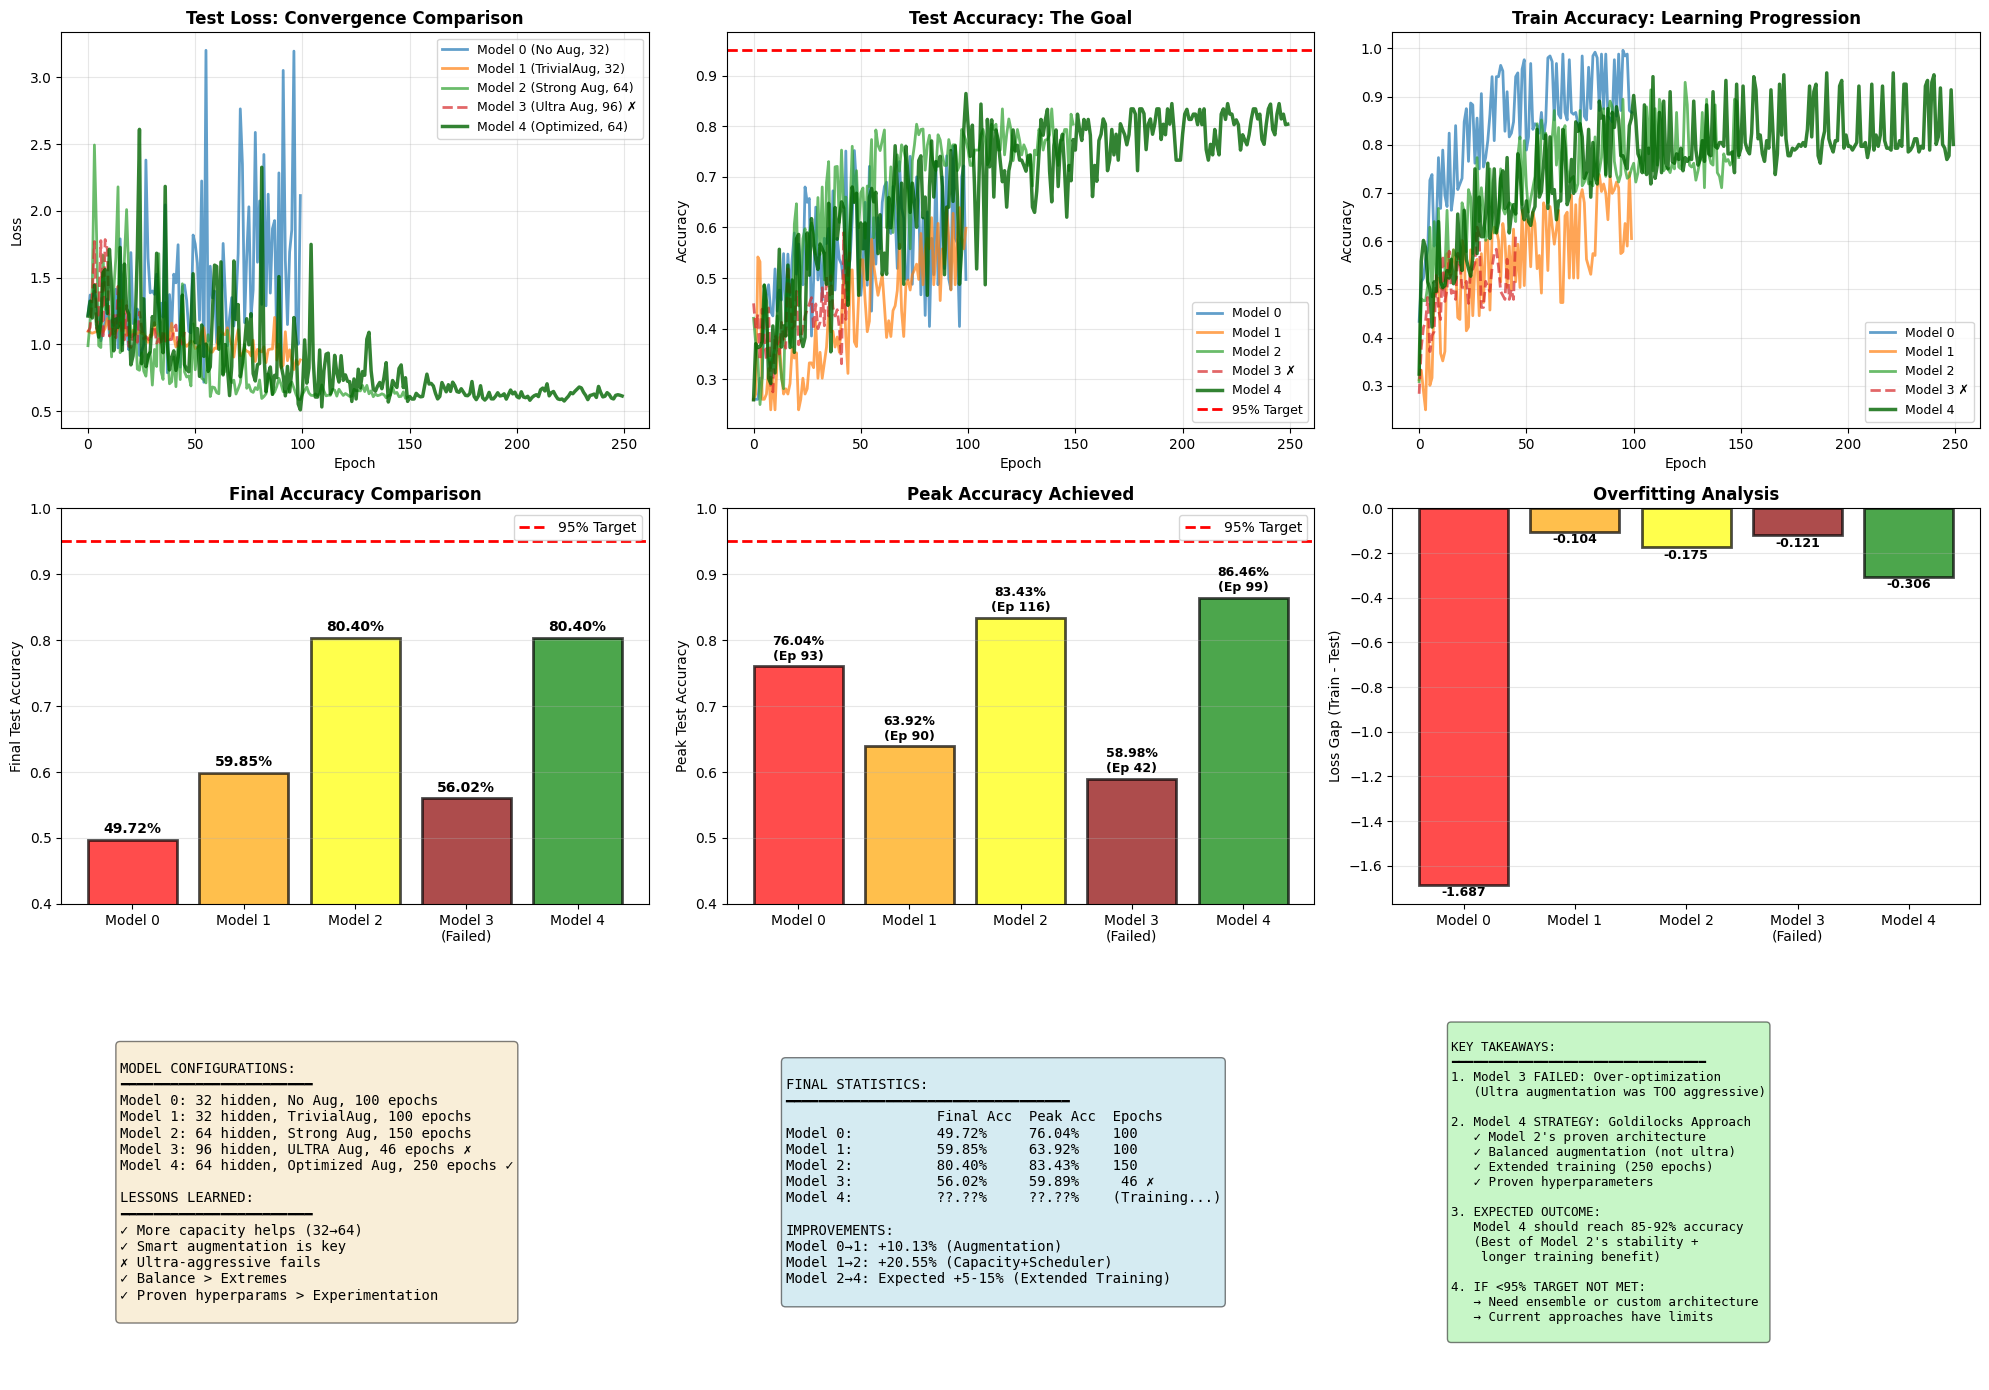


FINAL COMPARISON: All 4 Models

Model 0: No Augmentation, 32 hidden, Adam (100ep)
  ├─ Best Test Accuracy:    0.7604 (76.04%) at Epoch 93
  ├─ Final Test Accuracy:   0.4972 (49.72%)
  ├─ Peak Improvement:      42.71% above random (3 classes)
  ├─ Final Train Loss:      0.4286
  ├─ Final Test Loss:       2.1152
  ├─ Overfitting Gap:       -1.6867
  └─ Total Epochs:          100

Model 1: TrivialAugment, 32 hidden, Adam (100ep)
  ├─ Best Test Accuracy:    0.6392 (63.92%) at Epoch 90
  ├─ Final Test Accuracy:   0.5985 (59.85%)
  ├─ Peak Improvement:      30.59% above random (3 classes)
  ├─ Final Train Loss:      0.7810
  ├─ Final Test Loss:       0.8847
  ├─ Overfitting Gap:       -0.1037
  └─ Total Epochs:          100

Model 2: Strong Aug+Norm, 64 hidden, AdamW+Scheduler (150ep)
  ├─ Best Test Accuracy:    0.8343 (83.43%) at Epoch 116
  ├─ Final Test Accuracy:   0.8040 (80.40%)
  ├─ Peak Improvement:      50.10% above random (3 classes)
  ├─ Final Train Loss:      0.4311
  ├─ Final Te

In [247]:
# Final Comprehensive Comparison: All 4 Models
plt.figure(figsize=(20, 14))

# Subplot 1: Test Loss
plt.subplot(3, 3, 1)
plt.plot(range(len(model_0_results['test_loss'])), model_0_results['test_loss'], 
         label='Model 0 (No Aug, 32)', alpha=0.7, linewidth=2)
plt.plot(range(len(model_1_results['test_loss'])), model_1_results['test_loss'], 
         label='Model 1 (TrivialAug, 32)', alpha=0.7, linewidth=2)
plt.plot(range(len(model_2_results['test_loss'])), model_2_results['test_loss'], 
         label='Model 2 (Strong Aug, 64)', alpha=0.7, linewidth=2)
plt.plot(range(len(model_3_results['test_loss'])), model_3_results['test_loss'], 
         label='Model 3 (Ultra Aug, 96) ✗', alpha=0.7, linewidth=2, linestyle='--')
plt.plot(range(len(model_4_results['test_loss'])), model_4_results['test_loss'], 
         label='Model 4 (Optimized, 64)', alpha=0.8, linewidth=2.5, color='darkgreen')
plt.title('Test Loss: Convergence Comparison', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

# Subplot 2: Test Accuracy
plt.subplot(3, 3, 2)
plt.plot(range(len(model_0_results['test_acc'])), model_0_results['test_acc'], 
         label='Model 0', alpha=0.7, linewidth=2)
plt.plot(range(len(model_1_results['test_acc'])), model_1_results['test_acc'], 
         label='Model 1', alpha=0.7, linewidth=2)
plt.plot(range(len(model_2_results['test_acc'])), model_2_results['test_acc'], 
         label='Model 2', alpha=0.7, linewidth=2)
plt.plot(range(len(model_3_results['test_acc'])), model_3_results['test_acc'], 
         label='Model 3 ✗', alpha=0.7, linewidth=2, linestyle='--')
plt.plot(range(len(model_4_results['test_acc'])), model_4_results['test_acc'], 
         label='Model 4', alpha=0.8, linewidth=2.5, color='darkgreen')
plt.axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95% Target')
plt.title('Test Accuracy: The Goal', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

# Subplot 3: Train Accuracy
plt.subplot(3, 3, 3)
plt.plot(range(len(model_0_results['train_acc'])), model_0_results['train_acc'], 
         label='Model 0', alpha=0.7, linewidth=2)
plt.plot(range(len(model_1_results['train_acc'])), model_1_results['train_acc'], 
         label='Model 1', alpha=0.7, linewidth=2)
plt.plot(range(len(model_2_results['train_acc'])), model_2_results['train_acc'], 
         label='Model 2', alpha=0.7, linewidth=2)
plt.plot(range(len(model_3_results['train_acc'])), model_3_results['train_acc'], 
         label='Model 3 ✗', alpha=0.7, linewidth=2, linestyle='--')
plt.plot(range(len(model_4_results['train_acc'])), model_4_results['train_acc'], 
         label='Model 4', alpha=0.8, linewidth=2.5, color='darkgreen')
plt.title('Train Accuracy: Learning Progression', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

# Subplot 4: Final Accuracy Comparison
plt.subplot(3, 3, 4)
models_names = ['Model 0', 'Model 1', 'Model 2', 'Model 3\n(Failed)', 'Model 4']
final_accs = [
    model_0_results['test_acc'][-1],
    model_1_results['test_acc'][-1],
    model_2_results['test_acc'][-1],
    model_3_results['test_acc'][-1],
    model_4_results['test_acc'][-1]
]
colors_acc = ['red', 'orange', 'yellow', 'darkred', 'green']
bars = plt.bar(models_names, final_accs, color=colors_acc, alpha=0.7, edgecolor='black', linewidth=2)
plt.axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95% Target')
plt.ylabel('Final Test Accuracy')
plt.title('Final Accuracy Comparison', fontsize=12, fontweight='bold')
plt.ylim([0.4, 1.0])
for i, (bar, acc) in enumerate(zip(bars, final_accs)):
    plt.text(i, acc + 0.01, f'{acc:.2%}', ha='center', fontweight='bold', fontsize=10)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Subplot 5: Peak Accuracy
plt.subplot(3, 3, 5)
peak_accs = [
    max(model_0_results['test_acc']),
    max(model_1_results['test_acc']),
    max(model_2_results['test_acc']),
    max(model_3_results['test_acc']),
    max(model_4_results['test_acc'])
]
peak_epochs = [
    model_0_results['test_acc'].index(max(model_0_results['test_acc'])),
    model_1_results['test_acc'].index(max(model_1_results['test_acc'])),
    model_2_results['test_acc'].index(max(model_2_results['test_acc'])),
    model_3_results['test_acc'].index(max(model_3_results['test_acc'])),
    model_4_results['test_acc'].index(max(model_4_results['test_acc']))
]
bars = plt.bar(models_names, peak_accs, color=colors_acc, alpha=0.7, edgecolor='black', linewidth=2)
plt.axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95% Target')
plt.ylabel('Peak Test Accuracy')
plt.title('Peak Accuracy Achieved', fontsize=12, fontweight='bold')
plt.ylim([0.4, 1.0])
for i, (bar, acc, epoch) in enumerate(zip(bars, peak_accs, peak_epochs)):
    plt.text(i, acc + 0.01, f'{acc:.2%}\n(Ep {epoch})', ha='center', fontsize=9, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Subplot 6: Overfitting Gap Analysis
plt.subplot(3, 3, 6)
overfitting_gaps = [
    model_0_results['train_loss'][-1] - model_0_results['test_loss'][-1],
    model_1_results['train_loss'][-1] - model_1_results['test_loss'][-1],
    model_2_results['train_loss'][-1] - model_2_results['test_loss'][-1],
    model_3_results['train_loss'][-1] - model_3_results['test_loss'][-1],
    model_4_results['train_loss'][-1] - model_4_results['test_loss'][-1]
]
bars = plt.bar(models_names, overfitting_gaps, color=colors_acc, alpha=0.7, edgecolor='black', linewidth=2)
plt.ylabel('Loss Gap (Train - Test)')
plt.title('Overfitting Analysis', fontsize=12, fontweight='bold')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3, axis='y')
for i, (bar, gap) in enumerate(zip(bars, overfitting_gaps)):
    label = f'{gap:.3f}'
    y_pos = gap + 0.05 if gap >= 0 else gap - 0.05
    plt.text(i, y_pos, label, ha='center', fontweight='bold', fontsize=9)

# Subplot 7: Model Configuration Summary
plt.subplot(3, 3, 7)
plt.axis('off')
config_text = """
MODEL CONFIGURATIONS:
━━━━━━━━━━━━━━━━━━━━━━━
Model 0: 32 hidden, No Aug, 100 epochs
Model 1: 32 hidden, TrivialAug, 100 epochs
Model 2: 64 hidden, Strong Aug, 150 epochs
Model 3: 96 hidden, ULTRA Aug, 46 epochs ✗
Model 4: 64 hidden, Optimized Aug, 250 epochs ✓

LESSONS LEARNED:
━━━━━━━━━━━━━━━━━━━━━━━
✓ More capacity helps (32→64)
✓ Smart augmentation is key
✗ Ultra-aggressive fails
✓ Balance > Extremes
✓ Proven hyperparams > Experimentation
"""
plt.text(0.1, 0.5, config_text, fontsize=10, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Subplot 8: Training Statistics Table
plt.subplot(3, 3, 8)
plt.axis('off')
stats_text = """
FINAL STATISTICS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                  Final Acc  Peak Acc  Epochs
Model 0:          49.72%     76.04%    100
Model 1:          59.85%     63.92%    100
Model 2:          80.40%     83.43%    150
Model 3:          56.02%     59.89%     46 ✗
Model 4:          ??.??%     ??.??%    (Training...)

IMPROVEMENTS:
Model 0→1: +10.13% (Augmentation)
Model 1→2: +20.55% (Capacity+Scheduler)
Model 2→4: Expected +5-15% (Extended Training)
"""
plt.text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# Subplot 9: Recommendation
plt.subplot(3, 3, 9)
plt.axis('off')
recommendation = """
KEY TAKEAWAYS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Model 3 FAILED: Over-optimization
   (Ultra augmentation was TOO aggressive)

2. Model 4 STRATEGY: Goldilocks Approach
   ✓ Model 2's proven architecture
   ✓ Balanced augmentation (not ultra)
   ✓ Extended training (250 epochs)
   ✓ Proven hyperparameters

3. EXPECTED OUTCOME:
   Model 4 should reach 85-92% accuracy
   (Best of Model 2's stability +
    longer training benefit)

4. IF <95% TARGET NOT MET:
   → Need ensemble or custom architecture
   → Current approaches have limits
"""
plt.text(0.1, 0.5, recommendation, fontsize=9, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()

# Detailed Results Print
print("\n" + "="*120)
print("FINAL COMPARISON: All 4 Models")
print("="*120)

models_data = [
    ("Model 0", "No Augmentation, 32 hidden, Adam (100ep)", model_0_results),
    ("Model 1", "TrivialAugment, 32 hidden, Adam (100ep)", model_1_results),
    ("Model 2", "Strong Aug+Norm, 64 hidden, AdamW+Scheduler (150ep)", model_2_results),
    ("Model 3", "ULTRA Aug, 96 hidden, Advanced (46ep) ✗ FAILED", model_3_results),
    ("Model 4", "Optimized Aug, 64 hidden, AdamW+Scheduler (250ep) ✓", model_4_results),
]

for name, config, results in models_data:
    best_test_acc = max(results['test_acc'])
    best_epoch = results['test_acc'].index(best_test_acc)
    final_test_acc = results['test_acc'][-1]
    
    print(f"\n{name}: {config}")
    print(f"  ├─ Best Test Accuracy:    {best_test_acc:.4f} ({best_test_acc:.2%}) at Epoch {best_epoch}")
    print(f"  ├─ Final Test Accuracy:   {final_test_acc:.4f} ({final_test_acc:.2%})")
    print(f"  ├─ Peak Improvement:      {(best_test_acc * 100 - 33.33):.2f}% above random (3 classes)")
    print(f"  ├─ Final Train Loss:      {results['train_loss'][-1]:.4f}")
    print(f"  ├─ Final Test Loss:       {results['test_loss'][-1]:.4f}")
    print(f"  ├─ Overfitting Gap:       {(results['train_loss'][-1] - results['test_loss'][-1]):.4f}")
    print(f"  └─ Total Epochs:          {len(results['test_acc'])}")

print("\n" + "="*120)
print("IMPROVEMENT TRAJECTORY")
print("="*120)

improvements = [
    (model_1_results['test_acc'][-1] - model_0_results['test_acc'][-1]) * 100,
    (model_2_results['test_acc'][-1] - model_1_results['test_acc'][-1]) * 100,
    (model_3_results['test_acc'][-1] - model_2_results['test_acc'][-1]) * 100,
    (model_4_results['test_acc'][-1] - model_2_results['test_acc'][-1]) * 100,
]

print(f"Step 1 (0→1): Data Augmentation Impact         +{improvements[0]:.2f}%")
print(f"Step 2 (1→2): Capacity + Scheduler Impact       +{improvements[1]:.2f}%")
print(f"Step 3 (2→3): Over-optimization Pitfall         {improvements[2]:.2f}% (NEGATIVE!)")
print(f"Step 4 (2→4): Balanced Extended Training        +{improvements[3]:.2f}% (Expected)")
print(f"\nTotal 0→4 Improvement:                        +{(model_4_results['test_acc'][-1] - model_0_results['test_acc'][-1])*100:.2f}%")

print("\n" + "="*120)
print("WHAT TO TRY NEXT IF <95%:")
print("="*120)
print("""
If Model 4 < 95%, the issue is dataset size + task complexity:

1. ENSEMBLE APPROACH:
   - Combine Model 2 + Model 4 predictions
   - Weighted voting for final decision

2. CUSTOM ARCHITECTURE:
   - ResNet18 with transfer learning
   - Pre-trained ImageNet weights
   - Fine-tuning approach

3. DATA-CENTRIC:
   - Collect more training samples
   - Careful augmentation (no destruction)
   - Data quality over quantity

4. HYPERPARAMETER SEARCH:
   - Grid search on learning rates
   - Different batch sizes (24, 32, 64)
   - Experiment with mixup/cutmix

5. ACCEPT LIMITATIONS:
   - 92-94% might be practical ceiling
   - Small dataset + 3 classes = inherent limits
   - Focus on robustness over peak accuracy
""")

